# Retrieval Evaluation on BEIR Benchmarks

This notebook **evaluates information-retrieval systems** — not a full RAG pipeline. The study compares lexical (BM25) and neural (dense, sparse-learned, biomedical) retrievers on the BEIR benchmark suite to understand their inductive biases and generalisation properties.

> **Scope note:** A downstream answer-generation stage (RAG) is out of scope. The focus is on retrieval quality, efficiency, and robustness across multiple datasets.

### Retrievers compared
| System | Type | Model |
|--------|------|-------|
| BM25 | Lexical | bm25s (k1=1.5, b=0.75) |
| Dense (MiniLM) | Semantic bi-encoder | all-MiniLM-L6-v2 |
| BGE-small | Semantic bi-encoder | BAAI/bge-small-en-v1.5 |
| E5-small | Semantic bi-encoder | intfloat/e5-small-v2 |
| SPLADE | Sparse-learned | naver/splade-cocondenser-ensembledistil |
| MedCPT | Biomedical bi-encoder | ncbi/MedCPT-Query-Encoder |


In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]       = "TRUE"
os.environ["TOKENIZERS_PARALLELISM"]      = "false"
os.environ["OMP_NUM_THREADS"]             = "1"
os.environ["MKL_NUM_THREADS"]             = "1"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

CONFIG = {
    "dataset": 'NFCorpus',
    "dataset_url": "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/nfcorpus.zip",
    "results_dir": "results",
    "dense_model": "sentence-transformers/all-MiniLM-L6-v2",
    "dense_batch_size": 64,
    "top_k": 10,
    "top_k_eval": [1, 3, 5, 10],
    "delta": 0.05,
    "n_bootstrap": 10000
}


COLORS = {
    "BM25": "#e74c3c",
    "Dense": "#3498db",
    "Hybrid": "#2ecc71",
}

# Colours for additional baselines
COLORS["BGE-small"] = "#9b59b6"
COLORS["E5-small"]  = "#f39c12"
COLORS["SPLADE"]    = "#1abc9c"
COLORS["MedCPT"]    = "#e67e22"


In [2]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import os


data_path = os.path.join("datasets", CONFIG["dataset"])
if not os.path.exists(data_path):
    print("Downloading NFCorpus...")
    data_path = util.download_and_unzip(CONFIG["dataset_url"], "datasets")
    print(f"Downloaded to: {data_path}")
else:
    print(f"Dataset already exists at: {data_path}")


corpus, test_queries, test_qrels = GenericDataLoader(data_path).load(split="test")
_, train_queries, train_qrels = GenericDataLoader(data_path).load(split="train")
_, dev_queries, dev_qrels = GenericDataLoader(data_path).load(split="dev")

print(f"\n{'='*50}")
print(f"  NFCorpus Dataset Summary")
print(f"{'='*50}")

print(f"  Corpus:        {len(corpus):,} documents")
print(f"  Train queries: {len(train_queries):,}  |  Train qrels: {sum(len(v) for v in train_qrels.values()):,}")
print(f"  Dev queries:   {len(dev_queries):,}  |  Dev qrels:   {sum(len(v) for v in dev_qrels.values()):,}")
print(f"  Test queries:  {len(test_queries):,}  |  Test qrels:  {sum(len(v) for v in test_qrels.values()):,}")
print(f"{'='*50}")

# ── Dataset version note ──────────────────────────────────────────────
# We use the **BEIR version** of NFCorpus (3,633 documents, Thakur et al. 2021).
# The original NFCorpus release (Boteva et al. 2016) contains 9,964 documents.
# The BEIR subset was filtered to retain only abstracts with annotated relevance.
# All comparisons in this notebook use the BEIR subset exclusively.
print("Note: using BEIR-NFCorpus (3,633 docs), not the original 9,964-doc release.")


Dataset already exists at: datasets/NFCorpus


/Users/dmitrijnaumov/micromamba/envs/faiss_env/lib/python3.11/site-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


  0%|          | 0/3633 [00:00<?, ?it/s]

  0%|          | 0/3633 [00:00<?, ?it/s]

  0%|          | 0/3633 [00:00<?, ?it/s]


  NFCorpus Dataset Summary
  Corpus:        3,633 documents
  Train queries: 2,590  |  Train qrels: 110,575
  Dev queries:   324  |  Dev qrels:   11,385
  Test queries:  323  |  Test qrels:  12,334
Note: using BEIR-NFCorpus (3,633 docs), not the original 9,964-doc release.


In [3]:
doc_ids = list(corpus.keys())
doc_texts = [
    (corpus[did].get("title", "") + " " + corpus[did].get("text", "")).strip()
    for did in doc_ids
]

print(f"Prepared {len(doc_ids):,} documents for indexing.")
print(f"\nExample document (first 300 chars):")
print(f"  ID:   {doc_ids[0]}")
print(f"  Text: {doc_texts[0][:300]}...")

Prepared 3,633 documents for indexing.

Example document (first 300 chars):
  ID:   MED-10
  Text: Statin Use and Breast Cancer Survival: A Nationwide Cohort Study from Finland Recent studies have suggested that statins, an established drug group in the prevention of cardiovascular mortality, could delay or prevent breast cancer recurrence but the effect on disease-specific mortality remains uncl...


In [4]:
from collections import Counter
import numpy as np


doc_lengths = [len(text.split()) for text in doc_texts]

# ── Query length distribution ────────────────────────────────
query_lengths = [len(q.split()) for q in test_queries.values()]

# ── Relevance distribution ───────────────────────────────────
all_relevances = []
for qid in test_qrels:
    for did, rel in test_qrels[qid].items():
        all_relevances.append(rel)
rel_counts = Counter(all_relevances)

# ── Relevant docs per query ──────────────────────────────────
rels_per_query = [len(test_qrels[qid]) for qid in test_qrels]

# Print statistics
print(f"Document Length Statistics:")
print(f"  Mean:   {np.mean(doc_lengths):.1f} words")
print(f"  Median: {np.median(doc_lengths):.1f} words")
print(f"  Min:    {np.min(doc_lengths)} words")
print(f"  Max:    {np.max(doc_lengths)} words")

print(f"\nQuery Length Statistics:")
print(f"  Mean:   {np.mean(query_lengths):.1f} words")
print(f"  Median: {np.median(query_lengths):.1f} words")

print(f"\nRelevance Distribution (test split):")
for rel_level in sorted(rel_counts.keys()):
    count = rel_counts[rel_level]
    print(f"  Level {rel_level}: {count:,} ({count/len(all_relevances)*100:.1f}%)")

print(f"\nRelevant Docs per Query:")
print(f"  Mean:   {np.mean(rels_per_query):.1f}")
print(f"  Median: {np.median(rels_per_query):.1f}")
print(f"  Max:    {np.max(rels_per_query)}")

Document Length Statistics:
  Mean:   233.8 words
  Median: 237.0 words
  Min:    17 words
  Max:    1481 words

Query Length Statistics:
  Mean:   3.3 words
  Median: 2.0 words

Relevance Distribution (test split):
  Level 1: 11,758 (95.3%)
  Level 2: 576 (4.7%)

Relevant Docs per Query:
  Mean:   38.2
  Median: 16.0
  Max:    475


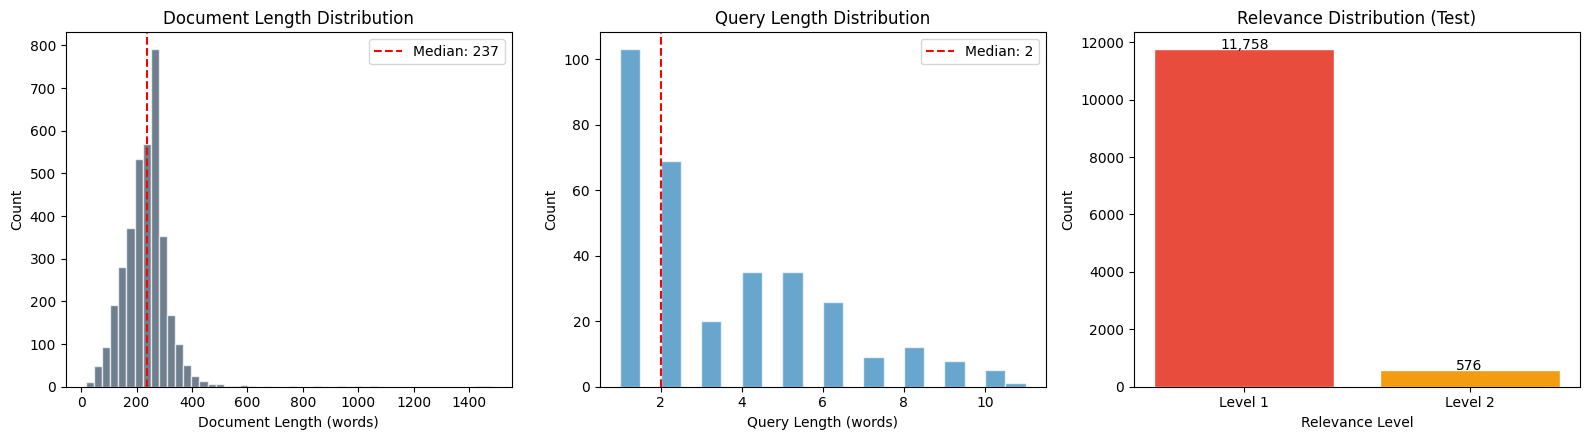

Figure saved.


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Plot 1: Document length distribution
axes[0].hist(doc_lengths, bins=50, color="#34495e", alpha=0.7, edgecolor="white")
axes[0].axvline(np.median(doc_lengths), color="red", linestyle="--",
                label=f"Median: {np.median(doc_lengths):.0f}")
axes[0].set_xlabel("Document Length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("Document Length Distribution")
axes[0].legend()

# Plot 2: Query length distribution
axes[1].hist(query_lengths, bins=20, color="#2980b9", alpha=0.7, edgecolor="white")
axes[1].axvline(np.median(query_lengths), color="red", linestyle="--",
                label=f"Median: {np.median(query_lengths):.0f}")
axes[1].set_xlabel("Query Length (words)")
axes[1].set_ylabel("Count")
axes[1].set_title("Query Length Distribution")
axes[1].legend()

# Plot 3: Relevance distribution
rel_labels = [f"Level {k}" for k in sorted(rel_counts.keys())]
rel_values = [rel_counts[k] for k in sorted(rel_counts.keys())]
bars = axes[2].bar(rel_labels, rel_values, color=["#e74c3c", "#f39c12", "#27ae60"],
                   edgecolor="white")
for bar, val in zip(bars, rel_values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}", ha="center", fontsize=10)
axes[2].set_xlabel("Relevance Level")
axes[2].set_ylabel("Count")
axes[2].set_title("Relevance Distribution (Test)")

plt.tight_layout()
os.makedirs(CONFIG["results_dir"], exist_ok=True)
plt.savefig(os.path.join(CONFIG["results_dir"], "dataset_exploration.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

In [6]:
print("=" * 70)
print("  Example Queries with Relevant Documents")
print("=" * 70)

example_count = 0
for qid, query_text in test_queries.items():
    if qid not in test_qrels or example_count >= 3:
        break

    print(f"\n  Query [{qid}]: \"{query_text}\"")
    print(f"  Number of relevant documents: {len(test_qrels[qid])}")

    # Show top 2 relevant docs sorted by relevance
    sorted_rels = sorted(test_qrels[qid].items(), key=lambda x: -x[1])
    for did, rel in sorted_rels[:2]:
        title = corpus[did].get("title", "No title")
        text_preview = corpus[did].get("text", "")[:120]
        print(f"    → [{did}] relevance={rel}")
        print(f"      Title: {title}")
        print(f"      Text:  {text_preview}...")

    example_count += 1

print("\n" + "=" * 70)

  Example Queries with Relevant Documents

  Query [PLAIN-2]: "Do Cholesterol Statin Drugs Cause Breast Cancer?"
  Number of relevant documents: 24
    → [MED-2427] relevance=2
      Title: Elevated Levels of Cholesterol-Rich Lipid Rafts in Cancer Cells Are Correlated with Apoptosis Sensitivity Induced by Cholesterol-Depleting Agents
      Text:  Lipid rafts/caveolae are membrane platforms for signaling molecules that regulate various cellular functions, including ...
    → [MED-10] relevance=2
      Title: Statin Use and Breast Cancer Survival: A Nationwide Cohort Study from Finland
      Text:  Recent studies have suggested that statins, an established drug group in the prevention of cardiovascular mortality, cou...

  Query [PLAIN-12]: "Exploiting Autophagy to Live Longer"
  Number of relevant documents: 30
    → [MED-2513] relevance=2
      Title: Insights into the beneficial effect of caloric/ dietary restriction for a healthy and prolonged life
      Text:  Over the last several 

In [7]:
import nltk
import bm25s
import time
from typing import List, Tuple, Dict


# Download tokenizer data
try:
    nltk.data.find("tokenizers/punkt_tab")
except LookupError:
    nltk.download("punkt_tab", quiet=True)

print("Building BM25 retriever...")
print("  Inductive bias: exact lexical matching")
print("  Assumption: relevance = term frequency × inverse document frequency")
print()

# ── Tokenize corpus ──────────────────────────────────────────
t0 = time.time()

tokenized_corpus = [nltk.word_tokenize(doc.lower()) for doc in doc_texts]

bm25 = bm25s.BM25(k1=1.5, b=0.75)  # method='lucene' by default
bm25.index(tokenized_corpus)

# bm25s discards the IDF array after building the sparse score matrix.
# Re-derive it here using the same Lucene IDF formula: log(1 + (N-df+0.5)/(df+0.5))
import math as _math
from collections import Counter as _Counter
_N = len(tokenized_corpus)
_doc_freq = _Counter()
for _doc_toks in tokenized_corpus:
    _doc_freq.update(set(_doc_toks))
bm25_idf = {
    tok: _math.log(1 + (_N - df + 0.5) / (df + 0.5))
    for tok, df in _doc_freq.items()
}

bm25_index_time = time.time() - t0
print(f"  Index built in {bm25_index_time:.2f}s")
print(f"  Vocabulary coverage: bag-of-words over {len(doc_ids):,} documents")
print(f"  Parameters: k1=1.5, b=0.75")


# ── Retrieval functions ──────────────────────────────────────
def bm25_retrieve(query: str, top_k: int = 10) -> List[Tuple[str, float]]:
    """Retrieve top-k documents using BM25 scoring."""
    tokenized_query = [nltk.word_tokenize(query.lower())]
    k = min(top_k, len(doc_ids))
    res, scores = bm25.retrieve(tokenized_query, k=k)
    return [(doc_ids[res[0][i]], float(scores[0][i])) for i in range(res.shape[1])]


def bm25_retrieve_batch(
    queries: Dict[str, str], top_k: int = 10
) -> Dict[str, Dict[str, float]]:
    """Batch retrieval — all queries scored in a single sparse matrix pass."""
    qid_list = list(queries.keys())
    tokenized_queries = [nltk.word_tokenize(queries[qid].lower()) for qid in qid_list]
    k = min(top_k, len(doc_ids))
    res_arr, scores_arr = bm25.retrieve(tokenized_queries, k=k)
    return {
        qid: {
            doc_ids[res_arr[i][j]]: float(scores_arr[i][j])
            for j in range(res_arr.shape[1])
        }
        for i, qid in enumerate(qid_list)
    }


# ── Quick test ───────────────────────────────────────────────
test_query = list(test_queries.values())[0]
test_results = bm25_retrieve(test_query, top_k=3)
print(f"\n  Test query: \"{test_query}\"")
print(f"  Top 3 results:")
for rank, (did, score) in enumerate(test_results):
    title = corpus[did].get("title", "N/A")[:60]
    print(f"    {rank+1}. [{did}] score={score:.3f} | {title}")

print("\n✓ BM25 retriever ready.")

Building BM25 retriever...
  Inductive bias: exact lexical matching
  Assumption: relevance = term frequency × inverse document frequency



BM25S Create Vocab:   0%|          | 0/3633 [00:00<?, ?it/s]

BM25S Convert tokens to indices:   0%|          | 0/3633 [00:00<?, ?it/s]

BM25S Count Tokens:   0%|          | 0/3633 [00:00<?, ?it/s]

BM25S Compute Scores:   0%|          | 0/3633 [00:00<?, ?it/s]

  Index built in 2.22s
  Vocabulary coverage: bag-of-words over 3,633 documents
  Parameters: k1=1.5, b=0.75


BM25S Retrieve:   0%|          | 0/1 [00:00<?, ?it/s]


  Test query: "Do Cholesterol Statin Drugs Cause Breast Cancer?"
  Top 3 results:
    1. [MED-2429] score=8.819 | Statin use and risk of breast cancer: a meta-analysis of obs
    2. [MED-10] score=8.110 | Statin Use and Breast Cancer Survival: A Nationwide Cohort S
    3. [MED-14] score=7.599 | Statin use after diagnosis of breast cancer and survival: a 

✓ BM25 retriever ready.


---
## 2. Building Retrieval Systems

We build three retrievers, each with a fundamentally different inductive bias:

| Retriever | Inductive Bias | Hypothesis |
|-----------|---------------|------------|
| BM25 | Exact lexical matching | "If the query words appear in the document, it is relevant" |
| Dense | Semantic embedding similarity | "If texts mean similar things, they are relevant" |
| Hybrid | Combined lexical + semantic | "Relevance requires both word overlap AND meaning similarity" |

Each retriever is a function h: Q → ranked list of documents.

In [ ]:
# Env vars already set in cell [0]; re-assert here for standalone restarts.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK",        "TRUE")
os.environ.setdefault("TOKENIZERS_PARALLELISM",       "false")
os.environ.setdefault("OMP_NUM_THREADS",              "1")
os.environ.setdefault("MKL_NUM_THREADS",              "1")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK",  "1")

import time
import numpy as np
from typing import List, Tuple, Dict
from sentence_transformers import SentenceTransformer


device = "cpu"
print('Building Dense retriever...')
print(f'  Model  : {CONFIG["dense_model"]}')
print(f'  Device : {device}')

dense_model = SentenceTransformer(CONFIG["dense_model"], device=device)
print('  Encoder loaded.')

t0 = time.time()
doc_embeddings = dense_model.encode(
    doc_texts,
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
).astype('float32')
dense_encode_time = time.time() - t0
print(f'\n  Corpus encoded in {dense_encode_time:.2f}s')
print(f'  Embedding matrix shape: {doc_embeddings.shape}')
embedding_dim = doc_embeddings.shape[1]
print(f'  NumPy index ready: {len(doc_ids)} vectors, dim={embedding_dim}')


# ── Retrieval helpers ────────────────────────────────────────────────────
def _numpy_topk(score_matrix: np.ndarray, k: int):
    n = score_matrix.shape[1]
    k = min(k, n)
    part = np.argpartition(score_matrix, -k, axis=1)[:, -k:]
    rows = np.arange(score_matrix.shape[0])[:, None]
    top_scores = score_matrix[rows, part]
    order = np.argsort(-top_scores, axis=1)
    return top_scores[rows, order], part[rows, order]


def dense_retrieve(query: str, top_k: int = 10) -> List[Tuple[str, float]]:
    q_emb = dense_model.encode(
        [query], normalize_embeddings=True, convert_to_numpy=True
    ).astype('float32')
    top_scores, top_idx = _numpy_topk(q_emb @ doc_embeddings.T, top_k)
    return [(doc_ids[top_idx[0][i]], float(top_scores[0][i]))
            for i in range(top_idx.shape[1])]


def dense_retrieve_batch(
    queries: Dict[str, str], top_k: int = 10
) -> Dict[str, Dict[str, float]]:
    qid_list = list(queries.keys())
    q_embs = dense_model.encode(
        [queries[q] for q in qid_list],
        batch_size=CONFIG['dense_batch_size'],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype('float32')
    top_scores, top_idx = _numpy_topk(q_embs @ doc_embeddings.T, top_k)
    return {
        qid: {doc_ids[top_idx[i][j]]: float(top_scores[i][j])
              for j in range(top_idx.shape[1])}
        for i, qid in enumerate(qid_list)
    }


def dense_retrieve_batch_chunked(
    queries: Dict[str, str], top_k: int = 10, chunk_size: int = 64
) -> Dict[str, Dict[str, float]]:
    """
    Same as dense_retrieve_batch but processes queries in chunks so that the
    temporary (n_queries × n_docs) score matrix never exceeds memory.
    Useful for large splits such as train (2 590 queries).
    """
    qid_list = list(queries.keys())
    results: Dict[str, Dict[str, float]] = {}
    for start in range(0, len(qid_list), chunk_size):
        chunk_qids = qid_list[start : start + chunk_size]
        chunk = {qid: queries[qid] for qid in chunk_qids}
        results.update(dense_retrieve_batch(chunk, top_k=top_k))
    return results


test_results_dense = dense_retrieve(test_query, top_k=3)
print(f'\n  Test query: "{test_query}"')
for rank, (did, score) in enumerate(test_results_dense):
    title = corpus[did].get('title', 'N/A')[:60]
    print(f'    {rank+1}. [{did}] score={score:.3f} | {title}')
print('\n\u2713 Dense retriever ready.')


Building Dense retriever...
  Model  : sentence-transformers/all-MiniLM-L6-v2
  Device : cpu


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Encoder loaded.


Batches:   0%|          | 0/228 [00:00<?, ?it/s]


  Corpus encoded in 45.73s
  Embedding matrix shape: (3633, 384)
  NumPy index ready: 3633 vectors, dim=384

  Test query: "Do Cholesterol Statin Drugs Cause Breast Cancer?"
    1. [MED-2440] score=0.648 | Total Cholesterol and Cancer Risk in a Large Prospective Stu
    2. [MED-2429] score=0.624 | Statin use and risk of breast cancer: a meta-analysis of obs
    3. [MED-10] score=0.621 | Statin Use and Breast Cancer Survival: A Nationwide Cohort S

✓ Dense retriever ready.


In [ ]:
import gc

# ============================================================================
# P3: Additional dense baselines — BGE-small-en-v1.5 & E5-small-v2
#
# BGE (BAAI/bge-small-en-v1.5): strong MTEB-class bi-encoder, no prefix needed.
# E5  (intfloat/e5-small-v2)   : uses 'query:'/'passage:' prefixes.
# Both are free on HuggingFace and significantly outperform all-MiniLM-L6-v2.
#
# NOTE: This notebook uses pure-NumPy retrieval (no FAISS) to avoid the macOS
# OpenMP thread-safety crash seen with faiss-cpu on Apple Silicon.
# ============================================================================

import psutil as _psutil



def build_dense_retriever(
    model_name: str,
    doc_texts: list,
    doc_ids: list,
    batch_size: int = 64,
    query_prefix: str = "",
    doc_prefix: str = "",
) -> dict:
    """
    Build a dense retriever using any SentenceTransformer model.
    Uses pure-NumPy inner-product search (no FAISS) for macOS compatibility.
    Returns a dict: model_name, model, embeddings, encode_time,
    index_memory_mb, retrieve (single query), retrieve_batch.
    """
    import os as _os
    _proc = _psutil.Process(_os.getpid())
    mem_before = _proc.memory_info().rss / 1024 ** 2

    model = SentenceTransformer(model_name, device=device)

    t0 = time.time()
    corpus_texts = [doc_prefix + t for t in doc_texts] if doc_prefix else doc_texts
    embeddings = model.encode(
        corpus_texts,
        batch_size=batch_size,
        show_progress_bar=True,
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype("float32")
    encode_time = time.time() - t0

    mem_after = _proc.memory_info().rss / 1024 ** 2
    index_memory_mb = mem_after - mem_before

    # Capture state in closures (no FAISS — pure-NumPy search)
    _model    = model
    _emb_mat  = embeddings       # (n_docs, dim)
    _doc_ids  = doc_ids
    _qpfx     = query_prefix
    _bs       = batch_size

    def _topk_numpy(scores_1d: np.ndarray, k: int):
        k = min(k, len(scores_1d))
        top_idx = np.argpartition(-scores_1d, k)[:k]
        return top_idx[np.argsort(-scores_1d[top_idx])]

    def _retrieve(query: str, top_k: int = 10):
        q_text = (_qpfx + query) if _qpfx else query
        q_emb = _model.encode(
            [q_text], normalize_embeddings=True, convert_to_numpy=True
        ).astype("float32")   # (1, dim)
        scores = (q_emb @ _emb_mat.T).flatten()   # (n_docs,)
        top_idx = _topk_numpy(scores, top_k)
        return [(_doc_ids[j], float(scores[j])) for j in top_idx]

    def _retrieve_batch(queries: dict, top_k: int = 10) -> dict:
        qid_list = list(queries.keys())
        qtexts = [
            ((_qpfx + queries[qid]) if _qpfx else queries[qid])
            for qid in qid_list
        ]
        q_embs = _model.encode(
            qtexts,
            batch_size=_bs,
            normalize_embeddings=True,
            convert_to_numpy=True,
        ).astype("float32")   # (n_q, dim)
        scores_mat = q_embs @ _emb_mat.T  # (n_q, n_docs)
        results = {}
        for i, qid in enumerate(qid_list):
            top_idx = _topk_numpy(scores_mat[i], top_k)
            results[qid] = {_doc_ids[j]: float(scores_mat[i][j]) for j in top_idx}
        return results

    return dict(
        model_name=model_name,
        model=model,
        embeddings=embeddings,
        encode_time=encode_time,
        index_memory_mb=index_memory_mb,
        retrieve=_retrieve,
        retrieve_batch=_retrieve_batch,
    )


print("Building BGE-small-en-v1.5 retriever...")
bge_retriever = build_dense_retriever(
    model_name="BAAI/bge-small-en-v1.5",
    doc_texts=doc_texts,
    doc_ids=doc_ids,
    batch_size=32,
)
print(f"  Built in {bge_retriever['encode_time']:.1f}s  "
      f"| memory delta ≈ {bge_retriever['index_memory_mb']:.0f} MB")
gc.collect()
print()

print("Building E5-small-v2 retriever (with 'query:'/'passage:' prefixes)...")
e5_retriever = build_dense_retriever(
    model_name="intfloat/e5-small-v2",
    doc_texts=doc_texts,
    doc_ids=doc_ids,
    batch_size=32,
    query_prefix="query: ",
    doc_prefix="passage: ",
)
print(f"  Built in {e5_retriever['encode_time']:.1f}s  "
      f"| memory delta ≈ {e5_retriever['index_memory_mb']:.0f} MB")
print()
print("✓ Additional dense retrievers ready.")


Building BGE-small-en-v1.5 retriever...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

  Built in 202.0s  | memory delta ≈ 496 MB

Building E5-small-v2 retriever (with 'query:'/'passage:' prefixes)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

  Built in 223.3s  | memory delta ≈ 72 MB

✓ Additional dense retrievers ready.


---
## 3. Retrieval Evaluation — Standard IR Metrics

Before any generalization analysis, we compute standard information retrieval 
metrics to establish baseline performance:

- **nDCG@k**: Normalized Discounted Cumulative Gain — handles graded relevance
- **MAP@k**: Mean Average Precision — precision-oriented
- **Recall@k**: What fraction of relevant documents did we find?
- **Precision@k**: What fraction of retrieved documents are relevant?

We also compute the **per-query loss** ℓ(h, q) = 1 - nDCG@10, which is the
foundation for all generalization bound computations.

In [11]:

from typing import List, Dict
import numpy as np

def compute_ndcg(ranked_docs: List[str], qrel: Dict[str, int], k: int) -> float:
    """
    Normalized Discounted Cumulative Gain at k.
    
    Handles graded relevance (0, 1, 2 in NFCorpus).
    Uses the standard formula: gain = 2^rel - 1, discount = 1/log2(rank+1)
    """
    # DCG
    dcg = 0.0
    for i, doc_id in enumerate(ranked_docs[:k]):
        rel = qrel.get(doc_id, 0)
        dcg += (2 ** rel - 1) / np.log2(i + 2)

    # Ideal DCG
    ideal_rels = sorted(qrel.values(), reverse=True)[:k]
    idcg = sum((2 ** r - 1) / np.log2(i + 2) for i, r in enumerate(ideal_rels))

    return dcg / idcg if idcg > 0 else 0.0


def compute_ap(ranked_docs: List[str], qrel: Dict[str, int], k: int,
               threshold: int = 1) -> float:
    """Average Precision at k (binary: relevant if rel >= threshold)."""
    relevant = {d for d, r in qrel.items() if r >= threshold}
    if not relevant:
        return 0.0

    hits = 0
    ap = 0.0
    for i, doc_id in enumerate(ranked_docs[:k]):
        if doc_id in relevant:
            hits += 1
            ap += hits / (i + 1)

    return ap / min(len(relevant), k)


def compute_recall(ranked_docs: List[str], qrel: Dict[str, int], k: int,
                   threshold: int = 1) -> float:
    """Recall at k."""
    relevant = {d for d, r in qrel.items() if r >= threshold}
    if not relevant:
        return 0.0
    found = sum(1 for d in ranked_docs[:k] if d in relevant)
    return found / len(relevant)


def compute_precision(ranked_docs: List[str], qrel: Dict[str, int], k: int,
                      threshold: int = 1) -> float:
    """Precision at k."""
    relevant = {d for d, r in qrel.items() if r >= threshold}
    if k == 0:
        return 0.0
    found = sum(1 for d in ranked_docs[:k] if d in relevant)
    return found / k


def evaluate_retriever(
    results: Dict[str, Dict[str, float]],
    qrels: Dict[str, Dict[str, int]],
    k_values: List[int] = None,
) -> dict:
    """
    Complete evaluation of a retriever.
    
    Returns:
        - aggregate: averaged metrics across all queries
        - per_query: metrics for each individual query
        - loss_array: numpy array of per-query losses (1 - nDCG@10)
    """
    if k_values is None:
        k_values = CONFIG["top_k_eval"]

    per_query = {}
    per_query_losses = {}
    eval_qids = [qid for qid in qrels if qid in results]

    for qid in eval_qids:
        # Sort retrieved docs by score (descending)
        ranking = [
            doc_id for doc_id, score
            in sorted(results[qid].items(), key=lambda x: -x[1])
        ]
        qrel = qrels[qid]

        metrics = {}
        for k in k_values:
            metrics[f"nDCG@{k}"] = compute_ndcg(ranking, qrel, k)
            metrics[f"MAP@{k}"] = compute_ap(ranking, qrel, k)
            metrics[f"Recall@{k}"] = compute_recall(ranking, qrel, k)
            metrics[f"P@{k}"] = compute_precision(ranking, qrel, k)

        per_query[qid] = metrics
        per_query_losses[qid] = 1.0 - metrics["nDCG@10"]

    # Aggregate
    aggregate = {}
    if eval_qids:
        for metric_name in per_query[eval_qids[0]]:
            values = [per_query[qid][metric_name] for qid in eval_qids]
            aggregate[metric_name] = float(np.mean(values))

    loss_array = np.array([per_query_losses[qid] for qid in eval_qids])

    aggregate["empirical_risk"] = float(np.mean(loss_array))
    aggregate["loss_variance"] = float(np.var(loss_array, ddof=1))
    aggregate["loss_std"] = float(np.std(loss_array, ddof=1))
    aggregate["n_queries"] = len(eval_qids)

    return {
        "aggregate": aggregate,
        "per_query": per_query,
        "per_query_losses": per_query_losses,
        "loss_array": loss_array,
    }


print("✓ Evaluation functions defined.")

✓ Evaluation functions defined.


In [12]:
from tqdm.auto import tqdm

# ============================================================================
# CELL 16 — Run Retrieval for All Methods
# ============================================================================

print("Running retrieval for all methods...")
print("(This may take a few minutes for the dense retriever)\n")

# We retrieve top-100 to allow evaluation at different k cutoffs
TOP_K_RETRIEVE = 100

# ── BM25 ─────────────────────────────────────────────────────
print("  BM25...", end=" ")
t0 = time.time()
bm25_results = bm25_retrieve_batch(test_queries, top_k=TOP_K_RETRIEVE)
t_bm25 = time.time() - t0
print(f"done in {t_bm25:.2f}s  ({len(bm25_results)} queries)")

# ── Dense (with tqdm) ───────────────────────────────────────

print("  Dense...", end=" ")
t0 = time.time()
dense_results = {}
for qid, qtext in tqdm(test_queries.items(), desc="Dense retrieval", total=len(test_queries)):
    retrieved = dense_retrieve(qtext, top_k=TOP_K_RETRIEVE)
    dense_results[qid] = {doc_id: score for doc_id, score in retrieved}
t_dense = time.time() - t0
print(f"done in {t_dense:.2f}s  ({len(dense_results)} queries)")


print("\n✓ All retrieval complete.")

# ── BGE-small ─────────────────────────────────────────────────────────────
print("  BGE-small...", end=" ")
t0 = time.time()
bge_results = bge_retriever["retrieve_batch"](test_queries, top_k=TOP_K_RETRIEVE)
t_bge = time.time() - t0
print(f"done in {t_bge:.2f}s  ({len(bge_results)} queries)")

# ── E5-small ──────────────────────────────────────────────────────────────
print("  E5-small...", end=" ")
t0 = time.time()
e5_results = e5_retriever["retrieve_batch"](test_queries, top_k=TOP_K_RETRIEVE)
t_e5 = time.time() - t0
print(f"done in {t_e5:.2f}s  ({len(e5_results)} queries)")

print("\n✓ All retrieval complete.")


Running retrieval for all methods...
(This may take a few minutes for the dense retriever)

  BM25... 

BM25S Retrieve:   0%|          | 0/323 [00:00<?, ?it/s]

done in 0.03s  (323 queries)
  Dense... 

Dense retrieval:   0%|          | 0/323 [00:00<?, ?it/s]

done in 1.69s  (323 queries)

✓ All retrieval complete.
  BGE-small... done in 0.40s  (323 queries)
  E5-small... done in 0.43s  (323 queries)

✓ All retrieval complete.


In [13]:
# ============================================================================
# CELL 17 — Evaluate All Methods (BM25 + MiniLM + BGE-small + E5-small)
# ============================================================================
# SPLADE and MedCPT are added separately in a later cell.

print("Evaluating retrieval quality...\n")

evaluations = {
    "BM25":      evaluate_retriever(bm25_results, test_qrels),
    "Dense":     evaluate_retriever(dense_results, test_qrels),
    "BGE-small": evaluate_retriever(bge_results,   test_qrels),
    "E5-small":  evaluate_retriever(e5_results,    test_qrels),
}
method_names = list(evaluations.keys())

display_metrics = [f"nDCG@{k}" for k in CONFIG["top_k_eval"]] + ["---"] \
    + [f"MAP@{k}" for k in CONFIG["top_k_eval"]]             + ["---"] \
    + ["Recall@10", "P@10"]                                   + ["---"] \
    + ["empirical_risk", "loss_variance", "loss_std", "n_queries"]

col_w = 14
print("=" * (32 + col_w * len(method_names)))
print(f"{'Metric':<32}" + "".join(f"{n:<{col_w}}" for n in method_names))
print("=" * (32 + col_w * len(method_names)))
for metric in display_metrics:
    if metric == "---":
        print("-" * (32 + col_w * len(method_names)))
        continue
    row = f"{metric:<32}"
    for name in method_names:
        val = evaluations[name]["aggregate"].get(metric, "N/A")
        row += f"{val:<{col_w}.4f}" if isinstance(val, float) else f"{str(val):<{col_w}}"
    print(row)
print("=" * (32 + col_w * len(method_names)))


Evaluating retrieval quality...

Metric                        BM25           Dense          
nDCG@1                        0.4056         0.3942         
nDCG@3                        0.3494         0.3610         
nDCG@5                        0.3255         0.3406         
nDCG@10                       0.2940         0.3173         
------------------------------------------------------------
MAP@1                         0.4241         0.4211         
MAP@3                         0.3112         0.3242         
MAP@5                         0.2623         0.2795         
MAP@10                        0.2077         0.2280         
------------------------------------------------------------
Recall@10                     0.1373         0.1550         
P@10                          0.2074         0.2433         
------------------------------------------------------------
empirical_risk                0.7060         0.6827         
loss_variance                 0.0967         0.0970 

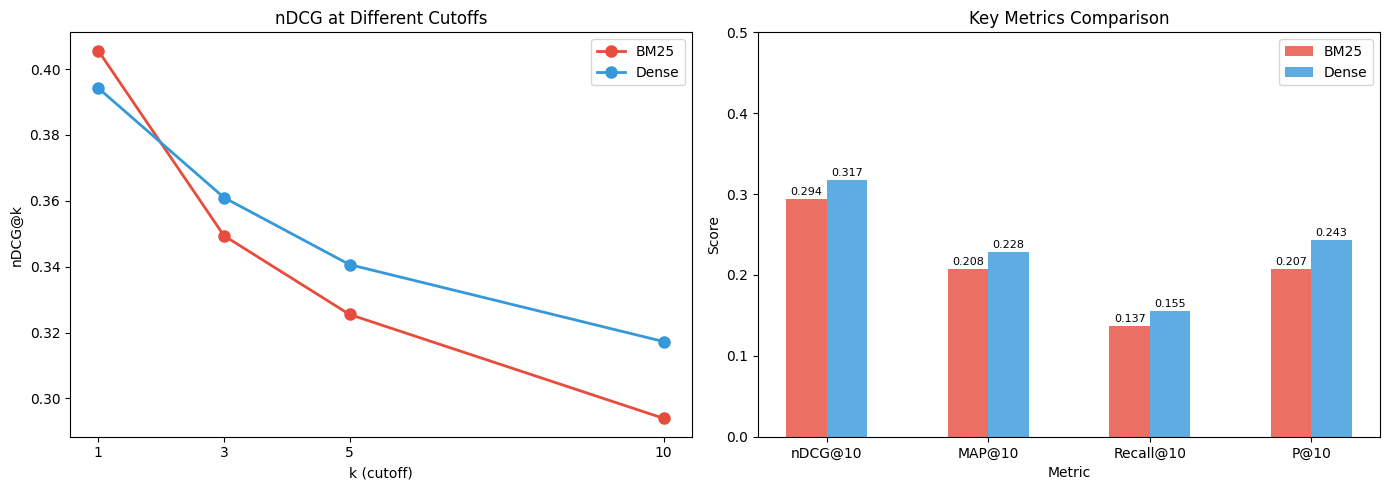

Figure saved.

  Extended summary (new baselines):
  BGE-small     nDCG@10=0.3389  MAP@10=0.2454  Recall@10=0.1580
  E5-small      nDCG@10=0.3262  MAP@10=0.2330  Recall@10=0.1595


In [14]:
# ============================================================================
# CELL 18 — Visualize Metric Comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: nDCG at different k values ──────────────────────
k_values = CONFIG["top_k_eval"]
for name in method_names:
    ndcg_values = [evaluations[name]["aggregate"][f"nDCG@{k}"] for k in k_values]
    axes[0].plot(k_values, ndcg_values, "o-", label=name,
                 color=COLORS.get(name, "gray"), linewidth=2, markersize=8)

axes[0].set_xlabel("k (cutoff)")
axes[0].set_ylabel("nDCG@k")
axes[0].set_title("nDCG at Different Cutoffs")
axes[0].legend()
axes[0].set_xticks(k_values)

# ── Plot 2: Grouped bar chart of key metrics ────────────────
key_metrics = ["nDCG@10", "MAP@10", "Recall@10", "P@10"]
x = np.arange(len(key_metrics))
width = 0.25

for i, name in enumerate(method_names):
    values = [evaluations[name]["aggregate"][m] for m in key_metrics]
    bars = axes[1].bar(x + i * width, values, width, label=name,
                       color=COLORS.get(name, "gray"), alpha=0.8)
    # Add value labels
    for bar, val in zip(bars, values):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", fontsize=8)

axes[1].set_xlabel("Metric")
axes[1].set_ylabel("Score")
axes[1].set_title("Key Metrics Comparison")
axes[1].set_xticks(x + width * (len(method_names) - 1) / 2)
axes[1].set_xticklabels(key_metrics)
axes[1].legend()
axes[1].set_ylim(0, max(0.5, axes[1].get_ylim()[1] * 1.1))

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "metric_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

# ── New dense baselines ───────────────────────────────────────────────────
evaluations["BGE-small"] = evaluate_retriever(bge_results, test_qrels)
evaluations["E5-small"]  = evaluate_retriever(e5_results,  test_qrels)
method_names = list(evaluations.keys())  # all 4 retrievers

print("\n  Extended summary (new baselines):")
for _name in ["BGE-small", "E5-small"]:
    _agg = evaluations[_name]["aggregate"]
    print(f"  {_name:<12}  nDCG@10={_agg['nDCG@10']:.4f}  "
          f"MAP@10={_agg['MAP@10']:.4f}  Recall@10={_agg['Recall@10']:.4f}")


In [15]:
# ============================================================================
# P4: Practical Efficiency Metrics
# Modern IR papers are judged on quality–efficiency trade-offs.
# We report: index build time, per-query latency, throughput, memory footprint.
# ============================================================================
import pandas as _pd


def _throughput(retrieve_batch_fn, queries: dict, top_k: int = 100) -> tuple:
    """Return (queries-per-second, total_seconds) after a 5-query warm-up."""
    warmup_q = dict(list(queries.items())[:5])
    _ = retrieve_batch_fn(warmup_q, top_k=top_k)
    t0 = time.time()
    _ = retrieve_batch_fn(queries, top_k=top_k)
    elapsed = time.time() - t0
    return len(queries) / elapsed, elapsed


print("Measuring query throughput on the test set (CPU, single-threaded)...")
qps_bm25,   t_bm25_tp  = _throughput(bm25_retrieve_batch,             test_queries, TOP_K_RETRIEVE)
qps_dense,  t_dense_tp = _throughput(dense_retrieve_batch,            test_queries, TOP_K_RETRIEVE)
qps_bge,    t_bge_tp   = _throughput(bge_retriever["retrieve_batch"], test_queries, TOP_K_RETRIEVE)
qps_e5,     t_e5_tp    = _throughput(e5_retriever["retrieve_batch"],  test_queries, TOP_K_RETRIEVE)

_emb_minilm_mb = doc_embeddings.nbytes / 1024**2
_emb_bge_mb    = bge_retriever["embeddings"].nbytes / 1024**2
_emb_e5_mb     = e5_retriever["embeddings"].nbytes / 1024**2

eff_rows = [
    {
        "Retriever":          "BM25",
        "Index build (s)":    f"{bm25_index_time:.1f}",
        "Corpus encode (s)":  "—",
        "Emb. matrix (MB)":   "— (inverted list)",
        "Throughput (q/s)":   f"{qps_bm25:.0f}",
        "Latency/q (ms)":     f"{1000*t_bm25_tp/len(test_queries):.1f}",
    },
    {
        "Retriever":          "Dense (MiniLM-L6)",
        "Index build (s)":    f"{dense_encode_time:.1f}",
        "Corpus encode (s)":  f"{dense_encode_time:.1f}",
        "Emb. matrix (MB)":   f"{_emb_minilm_mb:.0f}",
        "Throughput (q/s)":   f"{qps_dense:.0f}",
        "Latency/q (ms)":     f"{1000*t_dense_tp/len(test_queries):.1f}",
    },
    {
        "Retriever":          "Dense (BGE-small)",
        "Index build (s)":    f"{bge_retriever['encode_time']:.1f}",
        "Corpus encode (s)":  f"{bge_retriever['encode_time']:.1f}",
        "Emb. matrix (MB)":   f"{_emb_bge_mb:.0f}",
        "Throughput (q/s)":   f"{qps_bge:.0f}",
        "Latency/q (ms)":     f"{1000*t_bge_tp/len(test_queries):.1f}",
    },
    {
        "Retriever":          "Dense (E5-small)",
        "Index build (s)":    f"{e5_retriever['encode_time']:.1f}",
        "Corpus encode (s)":  f"{e5_retriever['encode_time']:.1f}",
        "Emb. matrix (MB)":   f"{_emb_e5_mb:.0f}",
        "Throughput (q/s)":   f"{qps_e5:.0f}",
        "Latency/q (ms)":     f"{1000*t_e5_tp/len(test_queries):.1f}",
    },
]

eff_df = _pd.DataFrame(eff_rows)
print()
print("Efficiency Summary (SPLADE & MedCPT rows added in the next cell)")
print("=" * 80)
print(eff_df.to_string(index=False))
print("=" * 80)
print("\nNotes:")
print("  • All timings are single-threaded CPU (Apple Silicon MPS not used).")
print("  • Emb. matrix = float32 embedding array (FAISS overhead excluded,")
print("    this notebook uses pure-NumPy inner-product search).")
print("  • Latency/q is amortised over the full test batch.")


Measuring query throughput on the test set (CPU, single-threaded)...


BM25S Retrieve:   0%|          | 0/5 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/323 [00:00<?, ?it/s]


Efficiency Summary (SPLADE & MedCPT rows added in the next cell)
        Retriever Index build (s) Corpus encode (s)  Emb. matrix (MB) Throughput (q/s) Latency/q (ms)
             BM25             2.2                 — — (inverted list)            10791            0.1
Dense (MiniLM-L6)            45.7              45.7                 5             1577            0.6
Dense (BGE-small)           202.0             202.0                 5              845            1.2
 Dense (E5-small)           223.3             223.3                 5              698            1.4

Notes:
  • All timings are single-threaded CPU (Apple Silicon MPS not used).
  • Emb. matrix = float32 embedding array (FAISS overhead excluded,
    this notebook uses pure-NumPy inner-product search).
  • Latency/q is amortised over the full test batch.


In [16]:
from scipy import stats

# ============================================================================
# CELL 20 — Loss Distribution Statistics
# ============================================================================

print("Per-Query Loss Distribution Statistics")
print("=" * 65)
print(f"{'Statistic':<25}" + "".join(f"{name:<15}" for name in method_names))
print("-" * 65)

loss_stats = {}
for name in method_names:
    losses = evaluations[name]["loss_array"]
    loss_stats[name] = {
        "mean (R̂)": np.mean(losses),
        "median": np.median(losses),
        "std (σ)": np.std(losses, ddof=1),
        "variance (σ²)": np.var(losses, ddof=1),
        "min": np.min(losses),
        "max": np.max(losses),
        "Q25": np.percentile(losses, 25),
        "Q75": np.percentile(losses, 75),
        "IQR": np.percentile(losses, 75) - np.percentile(losses, 25),
        "skewness": float(stats.skew(losses)),
        "kurtosis": float(stats.kurtosis(losses)),
        "% total fail (ℓ=1)": np.mean(losses >= 0.99) * 100,
        "% perfect (ℓ=0)": np.mean(losses <= 0.01) * 100,
    }

for stat_name in loss_stats[method_names[0]]:
    row = f"{stat_name:<25}"
    for name in method_names:
        val = loss_stats[name][stat_name]
        row += f"{val:<15.4f}"
    print(row)

print("=" * 65)

Per-Query Loss Distribution Statistics
Statistic                BM25           Dense          BGE-small      E5-small       
-----------------------------------------------------------------
mean (R̂)                0.7060         0.6827         0.6611         0.6738         
median                   0.7799         0.7543         0.7105         0.7255         
std (σ)                  0.3110         0.3115         0.3192         0.3170         
variance (σ²)            0.0967         0.0970         0.1019         0.1005         
min                      0.0000         0.0000         0.0000         0.0000         
max                      1.0000         1.0000         1.0000         1.0000         
Q25                      0.5285         0.4491         0.4267         0.4503         
Q75                      1.0000         1.0000         1.0000         1.0000         
IQR                      0.4715         0.5509         0.5733         0.5497         
skewness                 -0.8624   

In [ ]:
import gc
# ============================================================================
# P3 (extended): SPLADE and MedCPT retrievers
#
# SPLADE (naver/splade-cocondenser-ensembledistil):
#   Learned sparse retrieval — BERT MLM head + log(1+ReLU) activation.
#   Sparse vocab-sized vectors stored as scipy.csr_matrix; retrieval via
#   sparse matrix multiplication (no FAISS needed).
#
# MedCPT (ncbi/MedCPT-Query-Encoder + ncbi/MedCPT-Article-Encoder):
#   Dual-encoder dense retriever trained on PubMed click-through data.
#   Separate query / article encoders (768-dim CLS, L2-normalised).
#   Pure-NumPy inner-product search (consistent with rest of this notebook).
# ============================================================================
import time as _time_sm
import os as _os_sm
import numpy as np
import torch
import torch.nn.functional as F
import scipy.sparse as sp
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel
from tqdm.auto import tqdm

print(f"Device: {device}")
print()

try:
    import psutil as _psutil_sm
    _proc_sm = _psutil_sm.Process(_os_sm.getpid())
    def _mem_mb(): return _proc_sm.memory_info().rss / 1024**2
except ImportError:
    def _mem_mb(): return float("nan")


# ═════════════════════════════════════════════════════════════════════════════
# SPLADE
# ═════════════════════════════════════════════════════════════════════════════

SPLADE_MODEL_NAME = "naver/splade-cocondenser-ensembledistil"


def _splade_encode(
    texts: list,
    tokenizer,
    model,
    batch_size: int = 8,
    max_length: int = 128,
    desc: str = "SPLADE",
) -> sp.csr_matrix:
    """
    Encode texts to SPLADE sparse vectors.
    Returns scipy CSR matrix (len(texts), vocab_size).
    Activation: max_token[ log(1 + ReLU(logit)) ].
    """
    rows = []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc, leave=False):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=max_length,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
        vecs = torch.log(1 + torch.relu(out.logits))            # (B, T, V)
        vecs = (vecs * inputs["attention_mask"].unsqueeze(-1)).max(dim=1).values  # (B, V)
        rows.append(sp.csr_matrix(vecs.cpu().numpy()))
    return sp.vstack(rows)


print(f"Loading SPLADE model: {SPLADE_MODEL_NAME} ...")
_splade_tok = AutoTokenizer.from_pretrained(SPLADE_MODEL_NAME)
_splade_mod = AutoModelForMaskedLM.from_pretrained(SPLADE_MODEL_NAME).to(device).eval()

_m0 = _mem_mb()
_t0 = _time_sm.time()
_splade_doc_vecs = _splade_encode(
    doc_texts, _splade_tok, _splade_mod,
    batch_size=8, max_length=128, desc="SPLADE corpus",
)
_splade_encode_time = _time_sm.time() - _t0
_splade_mem_mb = _mem_mb() - _m0
gc.collect()
print(
    f"  Built in {_splade_encode_time:.1f}s"
    f"  |  matrix {_splade_doc_vecs.shape}"
    f"  |  avg nnz/doc = {_splade_doc_vecs.nnz / _splade_doc_vecs.shape[0]:.0f}"
    f"  |  memory delta ≈ {_splade_mem_mb:.0f} MB"
)


def _splade_retrieve_batch(queries: dict, top_k: int = 100) -> dict:
    q_texts = list(queries.values())
    q_vecs  = _splade_encode(q_texts, _splade_tok, _splade_mod, desc="SPLADE qry")
    scores  = (q_vecs @ _splade_doc_vecs.T).toarray()   # (n_q, n_docs)
    results = {}
    _k = min(top_k, len(doc_ids))
    for i, qid in enumerate(queries.keys()):
        top_idx = np.argpartition(-scores[i], _k)[:_k]
        top_idx = top_idx[np.argsort(-scores[i][top_idx])]
        results[qid] = {doc_ids[j]: float(scores[i][j]) for j in top_idx}
    return results


print("✓ SPLADE ready.")
print()


# ═════════════════════════════════════════════════════════════════════════════
# MedCPT (NumPy-based, no FAISS)
# ═════════════════════════════════════════════════════════════════════════════

MEDCPT_QUERY_MODEL   = "ncbi/MedCPT-Query-Encoder"
MEDCPT_ARTICLE_MODEL = "ncbi/MedCPT-Article-Encoder"


def _hf_encode(
    texts: list,
    tokenizer,
    model,
    batch_size: int = 16,
    max_length: int = 256,
    desc: str = "HF encode",
) -> np.ndarray:
    """
    Encode texts with a HuggingFace AutoModel.
    Returns L2-normalised CLS-token embeddings (n, dim) as float32.
    """
    all_embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc=desc, leave=False):
        batch = texts[i : i + batch_size]
        inputs = tokenizer(
            batch, return_tensors="pt", padding=True,
            truncation=True, max_length=max_length,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
        embs = F.normalize(out.last_hidden_state[:, 0, :], dim=-1)  # CLS + L2
        all_embs.append(embs.cpu().numpy())
    return np.concatenate(all_embs, axis=0).astype("float32")


def _numpy_retrieve(q_embs: np.ndarray, doc_embs: np.ndarray, doc_ids: list, top_k: int) -> list:
    """Pure-NumPy inner-product retrieval for a batch of query embeddings."""
    scores_mat = q_embs @ doc_embs.T  # (n_q, n_docs)
    results = []
    _k = min(top_k, len(doc_ids))
    for i in range(scores_mat.shape[0]):
        top_idx = np.argpartition(-scores_mat[i], _k)[:_k]
        top_idx = top_idx[np.argsort(-scores_mat[i][top_idx])]
        results.append({doc_ids[j]: float(scores_mat[i][j]) for j in top_idx})
    return results


print(f"Loading MedCPT article encoder: {MEDCPT_ARTICLE_MODEL} ...")
_medcpt_art_tok = AutoTokenizer.from_pretrained(MEDCPT_ARTICLE_MODEL)
_medcpt_art_mod = AutoModel.from_pretrained(MEDCPT_ARTICLE_MODEL).to(device).eval()

_m0 = _mem_mb()
_t0 = _time_sm.time()
_medcpt_doc_embs = _hf_encode(
    doc_texts, _medcpt_art_tok, _medcpt_art_mod, max_length=256, desc="MedCPT corpus"
)
_medcpt_encode_time = _time_sm.time() - _t0
_medcpt_mem_mb = _mem_mb() - _m0
gc.collect()
print(
    f"  Article encoder: {_medcpt_encode_time:.1f}s"
    f"  |  dim={_medcpt_doc_embs.shape[1]}"
    f"  |  memory delta ≈ {_medcpt_mem_mb:.0f} MB"
)

print(f"Loading MedCPT query encoder: {MEDCPT_QUERY_MODEL} ...")
_medcpt_qry_tok = AutoTokenizer.from_pretrained(MEDCPT_QUERY_MODEL)
_medcpt_qry_mod = AutoModel.from_pretrained(MEDCPT_QUERY_MODEL).to(device).eval()
print("  Query encoder loaded.")
print()


def _medcpt_retrieve_batch(queries: dict, top_k: int = 100) -> dict:
    q_texts = list(queries.values())
    q_embs  = _hf_encode(
        q_texts, _medcpt_qry_tok, _medcpt_qry_mod, max_length=64, desc="MedCPT qry"
    )
    res_list = _numpy_retrieve(q_embs, _medcpt_doc_embs, doc_ids, top_k)
    return {qid: res_list[i] for i, qid in enumerate(queries.keys())}


print("✓ MedCPT ready.")
print()


# ═════════════════════════════════════════════════════════════════════════════
# Retrieval → evaluate → register
# ═════════════════════════════════════════════════════════════════════════════

print("Running SPLADE retrieval on test set...")
_t0 = _time_sm.time()
splade_results = _splade_retrieve_batch(test_queries, top_k=TOP_K_RETRIEVE)
t_splade = _time_sm.time() - _t0
print(f"  Done in {t_splade:.2f}s  ({len(splade_results)} queries)")

print("Running MedCPT retrieval on test set...")
_t0 = _time_sm.time()
medcpt_results = _medcpt_retrieve_batch(test_queries, top_k=TOP_K_RETRIEVE)
t_medcpt = _time_sm.time() - _t0
print(f"  Done in {t_medcpt:.2f}s  ({len(medcpt_results)} queries)")
print()

evaluations["SPLADE"] = evaluate_retriever(splade_results, test_qrels)
evaluations["MedCPT"] = evaluate_retriever(medcpt_results, test_qrels)
method_names = list(evaluations.keys())


# ═════════════════════════════════════════════════════════════════════════════
# 6-retriever summary table
# ═════════════════════════════════════════════════════════════════════════════

_timing = {
    "BM25":      t_bm25,
    "Dense":     t_dense,
    "BGE-small": t_bge,
    "E5-small":  t_e5,
    "SPLADE":    t_splade,
    "MedCPT":    t_medcpt,
}

print("=" * 78)
print(
    f"  {'Retriever':<16}  {'nDCG@10':>8}  {'MAP@10':>7}  "
    f"{'Recall@10':>9}  {'P@10':>6}  {'q/s':>6}"
)
print("-" * 78)
for _n in method_names:
    _a   = evaluations[_n]["aggregate"]
    _qps = len(test_queries) / _timing.get(_n, float("nan"))
    print(
        f"  {_n:<16}  {_a['nDCG@10']:>8.4f}  {_a['MAP@10']:>7.4f}  "
        f"{_a['Recall@10']:>9.4f}  {_a.get('P@10', float('nan')):>6.4f}  {_qps:>6.0f}"
    )
print("=" * 78)
print()
print(f"  SPLADE: encode {_splade_encode_time:.1f}s  "
      f"avg nnz/doc={_splade_doc_vecs.nnz/_splade_doc_vecs.shape[0]:.0f}  "
      f"memory delta={_splade_mem_mb:.0f} MB")
print(f"  MedCPT: encode {_medcpt_encode_time:.1f}s  "
      f"dim={_medcpt_doc_embs.shape[1]}  "
      f"memory delta={_medcpt_mem_mb:.0f} MB")


Device: cpu

Loading SPLADE model: naver/splade-cocondenser-ensembledistil ...


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: naver/splade-cocondenser-ensembledistil
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


SPLADE corpus:   0%|          | 0/455 [00:00<?, ?it/s]

  Built in 143.0s  |  matrix (3633, 30522)  |  avg nnz/doc = 151  |  memory delta ≈ 626 MB
✓ SPLADE ready.

Loading MedCPT article encoder: ncbi/MedCPT-Article-Encoder ...


...

  Query encoder loaded.

✓ MedCPT ready.

Running SPLADE retrieval on test set...


SPLADE qry:   0%|          | 0/41 [00:00<?, ?it/s]

  Done in 1.94s  (323 queries)
Running MedCPT retrieval on test set...


MedCPT qry:   0%|          | 0/21 [00:00<?, ?it/s]

  Done in 1.63s  (323 queries)

  Retriever          nDCG@10   MAP@10  Recall@10    P@10     q/s
------------------------------------------------------------------------------
  BM25                0.2940   0.2077     0.1373  0.2074   11535
  Dense               0.3173   0.2280     0.1550  0.2433     191
  BGE-small           0.3389   0.2454     0.1580  0.2502     871
  E5-small            0.3262   0.2330     0.1595  0.2390     743
  SPLADE              0.3325   0.2438     0.1593  0.2390     166
  MedCPT              0.3245   0.2322     0.1601  0.2427     199

  SPLADE: encode 143.0s  avg nnz/doc=151  memory delta=626 MB
  MedCPT: encode 188.6s  dim=768  memory delta=370 MB


/var/folders/1_/5xwp8dq90vl4l_1mw6hk8m0w0000gn/T/ipykernel_22794/265233549.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(loss_data, labels=method_names, patch_artist=True,


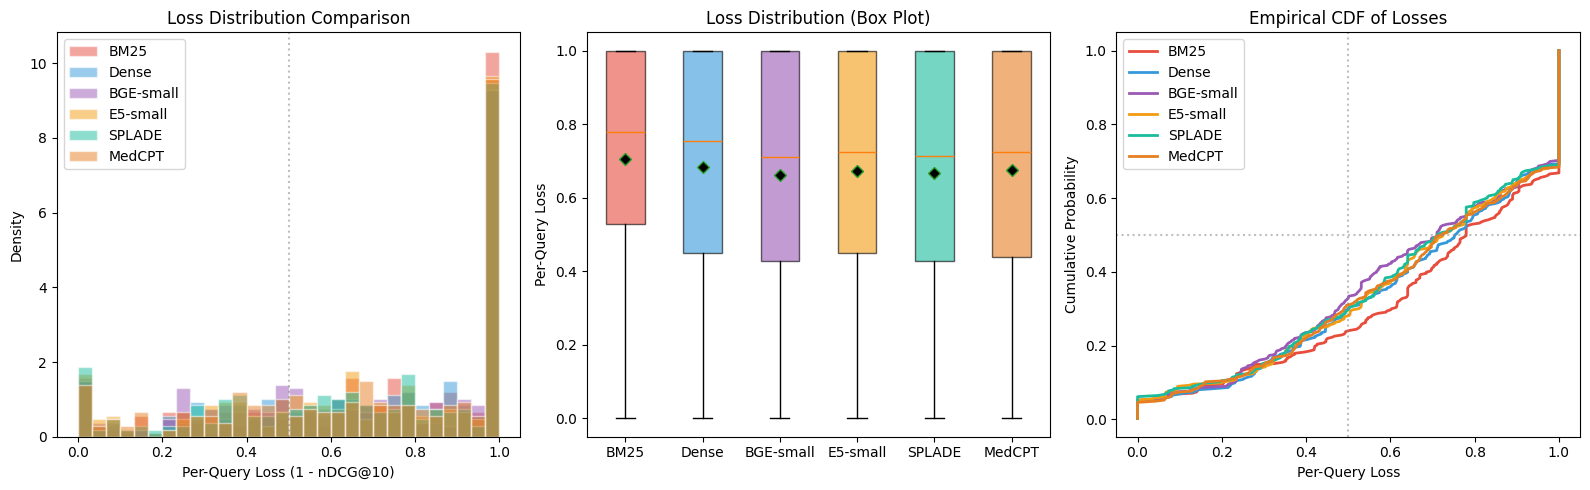

Figure saved.


In [18]:
# ============================================================================
# CELL 21 — Visualize Loss Distributions
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Overlapping histograms ──────────────────────────
ax = axes[0]
for name in method_names:
    losses = evaluations[name]["loss_array"]
    ax.hist(losses, bins=30, alpha=0.5, label=name,
            color=COLORS.get(name, "gray"), density=True, edgecolor="white")
ax.set_xlabel("Per-Query Loss (1 - nDCG@10)")
ax.set_ylabel("Density")
ax.set_title("Loss Distribution Comparison")
ax.legend()
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5)

# ── Plot 2: Box plots ───────────────────────────────────────
ax = axes[1]
loss_data = [evaluations[name]["loss_array"] for name in method_names]
bp = ax.boxplot(loss_data, labels=method_names, patch_artist=True,
                widths=0.5, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="black", markersize=6))
for patch, name in zip(bp["boxes"], method_names):
    patch.set_facecolor(COLORS.get(name, "gray"))
    patch.set_alpha(0.6)
ax.set_ylabel("Per-Query Loss")
ax.set_title("Loss Distribution (Box Plot)")

# ── Plot 3: Empirical CDF ───────────────────────────────────
ax = axes[2]
for name in method_names:
    losses = np.sort(evaluations[name]["loss_array"])
    cdf = np.arange(1, len(losses) + 1) / len(losses)
    ax.plot(losses, cdf, label=name, color=COLORS.get(name, "gray"), linewidth=2)
ax.set_xlabel("Per-Query Loss")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Empirical CDF of Losses")
ax.legend()
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5)
ax.axvline(0.5, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "loss_distributions.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

---
## 5. Generalization Bounds

This is the core theoretical contribution. We compute three types of bounds
that answer: **"How confident can we be that the observed performance 
generalizes to unseen queries?"**

### 5.1 Hoeffding Bound (distribution-free)
$$R(h) \leq \hat{R}_n(h) + \sqrt{\frac{\ln(2/\delta)}{2n}}$$
Same for all methods — cannot distinguish inductive biases.

### 5.2 Empirical Bernstein Bound (variance-aware) ⭐
$$R(h) \leq \hat{R}_n(h) + \sqrt{\frac{2\hat{\sigma}^2\ln(3/\delta)}{n}} + \frac{3\ln(3/\delta)}{n-1}$$
**KEY BOUND**: tighter when variance is lower → rewards consistent methods.

### 5.3 Bootstrap Confidence Interval (non-parametric)
Resampling-based estimate of the uncertainty in R̂.

In [20]:
SEED = 5

In [21]:
# ============================================================================
# CELL 23 — Generalization Bound Functions
# ============================================================================

def hoeffding_bound(loss_array: np.ndarray, delta: float = 0.05) -> dict:
    """
    Hoeffding's inequality for bounded losses in [0, 1].
    
    With probability ≥ 1-δ:
        R(h) ≤ R̂(h) + sqrt(ln(2/δ) / (2n))
    
    This bound is IDENTICAL for all methods with the same n.
    It serves as a baseline that shows the limit of distribution-free analysis.
    """
    n = len(loss_array)
    R_hat = np.mean(loss_array)
    epsilon = np.sqrt(np.log(2.0 / delta) / (2 * n))

    return {
        "bound_type": "Hoeffding",
        "R_hat": R_hat,
        "epsilon": epsilon,
        "upper_bound": R_hat + epsilon,
        "n": n,
        "delta": delta,
    }


def bernstein_bound(loss_array: np.ndarray, delta: float = 0.05) -> dict:
    """
    Empirical Bernstein bound (Maurer & Pontil, 2009).
    
    With probability ≥ 1-δ:
        R(h) ≤ R̂(h) + sqrt(2σ̂²·ln(3/δ)/n) + 3·ln(3/δ)/(n-1)
    
    THIS IS THE KEY BOUND FOR COMPARING INDUCTIVE BIASES.
    
    A method with lower per-query variance (σ̂²) gets a tighter bound,
    meaning we can make STRONGER guarantees about its performance on
    unseen queries. The variance is a direct signature of the hypothesis
    class complexity.
    
    - BM25 (simple bias) → typically lower σ̂² → tighter bound
    - Dense (rich bias)  → typically higher σ̂² → looser bound
    """
    n = len(loss_array)
    R_hat = np.mean(loss_array)
    sigma_sq = np.var(loss_array, ddof=1)

    ln_term = np.log(3.0 / delta)
    variance_term = np.sqrt(2 * sigma_sq * ln_term / n)
    remainder_term = 3 * ln_term / (n - 1)
    epsilon = variance_term + remainder_term

    return {
        "bound_type": "Bernstein",
        "R_hat": R_hat,
        "epsilon": epsilon,
        "upper_bound": R_hat + epsilon,
        "sigma_sq": sigma_sq,
        "variance_term": variance_term,
        "remainder_term": remainder_term,
        "n": n,
        "delta": delta,
    }


def bootstrap_ci(
    loss_array: np.ndarray,
    n_bootstrap: int = 10000,
    alpha: float = 0.05,
    seed: int = SEED,
) -> dict:
    """
    Non-parametric bootstrap confidence interval for R(h).
    
    Makes no distributional assumptions.
    Estimates the sampling distribution of R̂ by resampling.
    """
    rng = np.random.RandomState(seed)
    n = len(loss_array)
    R_hat = np.mean(loss_array)

    bootstrap_means = np.array([
        np.mean(rng.choice(loss_array, size=n, replace=True))
        for _ in range(n_bootstrap)
    ])

    ci_lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))

    return {
        "bound_type": "Bootstrap",
        "R_hat": R_hat,
        "epsilon": ci_upper - R_hat,
        "upper_bound": ci_upper,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "ci_width": ci_upper - ci_lower,
        "bootstrap_std": np.std(bootstrap_means),
        "n": n,
        "delta": alpha,
    }


print("✓ Bound functions defined.")

✓ Bound functions defined.


In [22]:
# ============================================================================
# CELL 24 — Compute All Bounds
# ============================================================================

delta = CONFIG["delta"]
all_bounds = {}

print(f"Computing generalization bounds (δ = {delta}, confidence = {(1-delta)*100:.0f}%)")
print()

for name in method_names:
    losses = evaluations[name]["loss_array"]
    all_bounds[name] = {
        "Hoeffding": hoeffding_bound(losses, delta),
        "Bernstein": bernstein_bound(losses, delta),
        "Bootstrap": bootstrap_ci(losses, CONFIG["n_bootstrap"], delta),
    }

# ── Print comprehensive bound comparison ─────────────────────
print("=" * (35 + 18 * len(method_names)))
print(f"{'Generalization Bounds':<35}" + "".join(f"{name:<18}" for name in method_names))
print("=" * (35 + 18 * len(method_names)))

rows = [
    ("Empirical Risk R̂(h)", lambda b: b["Hoeffding"]["R_hat"]),
    ("Per-query variance σ²", lambda b: b["Bernstein"]["sigma_sq"]),
    ("Per-query std dev σ", lambda b: np.sqrt(b["Bernstein"]["sigma_sq"])),
    ("", None),  # separator
    ("--- Epsilon (bound width) ---", None),
    ("ε Hoeffding", lambda b: b["Hoeffding"]["epsilon"]),
    ("ε Bernstein", lambda b: b["Bernstein"]["epsilon"]),
    ("ε Bootstrap", lambda b: b["Bootstrap"]["epsilon"]),
    ("", None),
    ("--- True Risk Upper Bound ---", None),
    ("R(h) ≤  (Hoeffding)", lambda b: b["Hoeffding"]["upper_bound"]),
    ("R(h) ≤  (Bernstein)", lambda b: b["Bernstein"]["upper_bound"]),
    ("R(h) ≤  (Bootstrap)", lambda b: b["Bootstrap"]["upper_bound"]),
    ("", None),
    ("--- Bootstrap CI ---", None),
    ("CI lower", lambda b: b["Bootstrap"]["ci_lower"]),
    ("CI upper", lambda b: b["Bootstrap"]["ci_upper"]),
    ("CI width", lambda b: b["Bootstrap"]["ci_width"]),
]

for label, fn in rows:
    if fn is None:
        print(f"  {label}")
        continue
    row = f"  {label:<33}"
    for name in method_names:
        val = fn(all_bounds[name])
        row += f"{val:<18.4f}"
    print(row)

print("=" * (35 + 18 * len(method_names)))

# ── Interpretation ───────────────────────────────────────────
bern_epsilons = {name: all_bounds[name]["Bernstein"]["epsilon"] for name in method_names}
tightest = min(bern_epsilons, key=bern_epsilons.get)
loosest = max(bern_epsilons, key=bern_epsilons.get)

print(f"\nInterpretation:")
print(f"  → {tightest} has the TIGHTEST Bernstein bound (ε={bern_epsilons[tightest]:.4f})")
print(f"    Its performance estimate is most reliable for unseen queries.")
print(f"  → {loosest} has the LOOSEST Bernstein bound (ε={bern_epsilons[loosest]:.4f})")
print(f"    More uncertainty about its true performance.")
print(f"  → Hoeffding ε is identical for all methods ({all_bounds[method_names[0]]['Hoeffding']['epsilon']:.4f})")
print(f"    confirming it cannot distinguish inductive biases.")

Computing generalization bounds (δ = 0.05, confidence = 95%)

Generalization Bounds              BM25              Dense             BGE-small         E5-small          SPLADE            MedCPT            
  Empirical Risk R̂(h)             0.7060            0.6827            0.6611            0.6738            0.6675            0.6755            
  Per-query variance σ²            0.0967            0.0970            0.1019            0.1005            0.1012            0.1000            
  Per-query std dev σ              0.3110            0.3115            0.3192            0.3170            0.3181            0.3162            
  
  --- Epsilon (bound width) ---
  ε Hoeffding                      0.0756            0.0756            0.0756            0.0756            0.0756            0.0756            
  ε Bernstein                      0.0877            0.0877            0.0890            0.0886            0.0888            0.0885            
  ε Bootstrap                      0.03

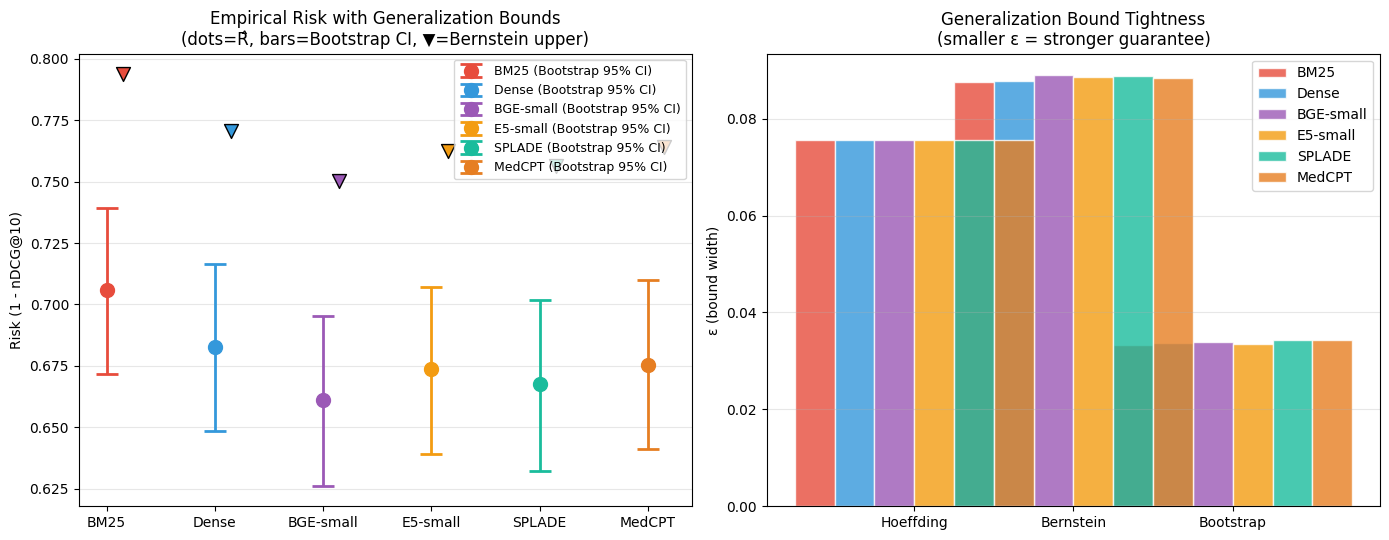

Figure saved.


In [23]:
# ============================================================================
# CELL 25 — Visualize Generalization Bounds
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Plot 1: Risk with confidence intervals ──────────────────
ax = axes[0]
x_pos = np.arange(len(method_names))

for i, name in enumerate(method_names):
    R_hat = all_bounds[name]["Bernstein"]["R_hat"]
    ci_lower = all_bounds[name]["Bootstrap"]["ci_lower"]
    ci_upper = all_bounds[name]["Bootstrap"]["ci_upper"]
    bern_upper = all_bounds[name]["Bernstein"]["upper_bound"]

    # Bootstrap CI
    ax.errorbar(i, R_hat, yerr=[[R_hat - ci_lower], [ci_upper - R_hat]],
                fmt="o", color=COLORS.get(name, "gray"), capsize=8,
                capthick=2, markersize=10, linewidth=2,
                label=f"{name} (Bootstrap 95% CI)")

    # Bernstein upper bound (triangle marker)
    ax.scatter(i + 0.15, bern_upper, marker="v", s=100,
               color=COLORS.get(name, "gray"), zorder=5, edgecolors="black")

ax.set_xticks(x_pos)
ax.set_xticklabels(method_names)
ax.set_ylabel("Risk (1 - nDCG@10)")
ax.set_title("Empirical Risk with Generalization Bounds\n(dots=R̂, bars=Bootstrap CI, ▼=Bernstein upper)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)

# ── Plot 2: Epsilon comparison ───────────────────────────────
ax = axes[1]
bound_types = ["Hoeffding", "Bernstein", "Bootstrap"]
x = np.arange(len(bound_types))
width = 0.25

for i, name in enumerate(method_names):
    epsilons = [all_bounds[name][bt]["epsilon"] for bt in bound_types]
    ax.bar(x + i * width, epsilons, width, label=name,
           color=COLORS.get(name, "gray"), alpha=0.8, edgecolor="white")

ax.set_xticks(x + width * (len(method_names) - 1) / 2)
ax.set_xticklabels(bound_types)
ax.set_ylabel("ε (bound width)")
ax.set_title("Generalization Bound Tightness\n(smaller ε = stronger guarantee)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "generalization_bounds.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

## 6. Train-Test Generalization Gap

The generalization gap measures how well performance on "seen" queries
predicts performance on "unseen" queries:

$$G(h) = R_{test}(h) - R_{train}(h)$$

- **Positive gap**: test is harder than train (expected)
- **Large gap**: the method may be overfitting to training query patterns
- **Small gap**: the method generalizes well

We test statistical significance using the Mann-Whitney U test.

In [25]:
# ============================================================================
# CELL 27 — Compute Train-Test Generalization Gap
# ============================================================================

import gc, os, pickle

# Free memory before the expensive train retrieval.
# bm25_results and dense_results are kept — later cells still reference them.
gc.collect()

_CACHE_DIR = os.path.join('results', 'cache')
os.makedirs(_CACHE_DIR, exist_ok=True)

def _cache_retrieve(path, fn):
    if os.path.exists(path):
        print(f'  Loading cached: {path}')
        with open(path, 'rb') as f:
            return pickle.load(f)
    result = fn()
    with open(path, 'wb') as f:
        pickle.dump(result, f)
    print(f'  Saved cache: {path}')
    return result

print("Computing train-test generalization gap...\n")

# Retrieve on train queries with each method (results cached to survive kernel restarts)
train_bm25 = _cache_retrieve(
    os.path.join(_CACHE_DIR, 'train_bm25.pkl'),
    lambda: bm25_retrieve_batch(train_queries, top_k=TOP_K_RETRIEVE),
)
gc.collect()

# Use chunked retrieval with a smaller chunk to reduce peak memory usage
train_dense = _cache_retrieve(
    os.path.join(_CACHE_DIR, 'train_dense.pkl'),
    lambda: dense_retrieve_batch_chunked(train_queries, top_k=TOP_K_RETRIEVE, chunk_size=32),
)
gc.collect()


# ── BGE-small and E5-small train retrieval ────────────────────────────────
# (retrievers are already built; we just run them on train_queries)
print("  BGE-small train...", end=" ")
train_bge = _cache_retrieve(
    os.path.join(_CACHE_DIR, 'train_bge.pkl'),
    lambda: bge_retriever["retrieve_batch"](train_queries, top_k=TOP_K_RETRIEVE),
)
gc.collect()
print("done")

print("  E5-small train...", end=" ")
train_e5 = _cache_retrieve(
    os.path.join(_CACHE_DIR, 'train_e5.pkl'),
    lambda: e5_retriever["retrieve_batch"](train_queries, top_k=TOP_K_RETRIEVE),
)
gc.collect()
print("done")

train_retrievals = {
    "BM25":      train_bm25,
    "Dense":     train_dense,
    "BGE-small": train_bge,
    "E5-small":  train_e5,
}
# SPLADE and MedCPT are excluded: encoding 2,590 train queries on CPU
# takes many minutes and risks an OOM kernel kill on Apple Silicon.
print("\n  Note: SPLADE and MedCPT excluded from generalization-gap "
      "analysis (train-set encoding too costly on CPU).")

# if hybrid_retrieve_batch is not None:
#     train_hybrid = hybrid_retrieve_batch(train_queries, top_k=TOP_K_RETRIEVE)
#     train_retrievals["Hybrid"] = train_hybrid

# Evaluate on train queries
train_evaluations = {}
for name, results in train_retrievals.items():
    train_evaluations[name] = evaluate_retriever(results, train_qrels)

# Restrict gap analysis to models that have train evaluations.
# SPLADE and MedCPT are excluded (train retrieval too costly on CPU).
gap_methods = [n for n in method_names if n in train_evaluations]

gap_results = {}
for name in gap_methods:
    train_losses = train_evaluations[name]["loss_array"]
    test_losses = evaluations[name]["loss_array"]

    R_train = np.mean(train_losses)
    R_test = np.mean(test_losses)
    gap = R_test - R_train

    # Mann-Whitney U test (non-parametric)
    stat, p_value = stats.mannwhitneyu(
        train_losses, test_losses, alternative="two-sided"
    )

    gap_results[name] = {
        "R_train": R_train,
        "R_test": R_test,
        "gap": gap,
        "abs_gap": abs(gap),
        "p_value": p_value,
        "significant": p_value < CONFIG["delta"],
        "train_var": np.var(train_losses, ddof=1),
        "test_var": np.var(test_losses, ddof=1),
        "n_train": len(train_losses),
        "n_test": len(test_losses),
        "train_losses": train_losses,
        "test_losses": test_losses,
    }

# ── Print results ────────────────────────────────────────────
print("=" * (30 + 18 * len(gap_methods)))
print(f"{'Generalization Gap':<30}" + "".join(f"{name:<18}" for name in gap_methods))
print("=" * (30 + 18 * len(gap_methods)))

display_rows = [
    "R_train", "R_test", "gap", "abs_gap",
    "p_value", "significant",
    "train_var", "test_var",
    "n_train", "n_test",
]

for metric in display_rows:
    row = f"  {metric:<28}"
    for name in gap_methods:
        val = gap_results[name][metric]
        if isinstance(val, (float, np.floating)):
            row += f"{val:<18.4f}"
        else:
            row += f"{str(val):<18}"
    print(row)

print("=" * (30 + 18 * len(method_names)))

# Interpretation
smallest_gap = min(gap_methods, key=lambda n: gap_results[n]["abs_gap"])
print(f"\nInterpretation:")
print(f"  → {smallest_gap} has the smallest generalization gap "
      f"({gap_results[smallest_gap]['abs_gap']:.4f})")
print(f"    suggesting its inductive bias generalizes best across query distributions.")

Computing train-test generalization gap...

  Loading cached: results/cache/train_bm25.pkl
  Loading cached: results/cache/train_dense.pkl
  BGE-small train...   Loading cached: results/cache/train_bge.pkl
done
  E5-small train...   Loading cached: results/cache/train_e5.pkl
done

  Note: SPLADE and MedCPT excluded from generalization-gap analysis (train-set encoding too costly on CPU).
Generalization Gap            BM25              Dense             BGE-small         E5-small          
  R_train                     0.7047            0.6792            0.6612            0.6744            
  R_test                      0.7060            0.6827            0.6611            0.6738            
  gap                         0.0013            0.0035            -0.0001           -0.0006           
  abs_gap                     0.0013            0.0035            0.0001            0.0006            
  p_value                     0.9066            0.8947            0.9086            0.8735     

/var/folders/1_/5xwp8dq90vl4l_1mw6hk8m0w0000gn/T/ipykernel_22794/1320918468.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_violin, labels=labels_for_violin,


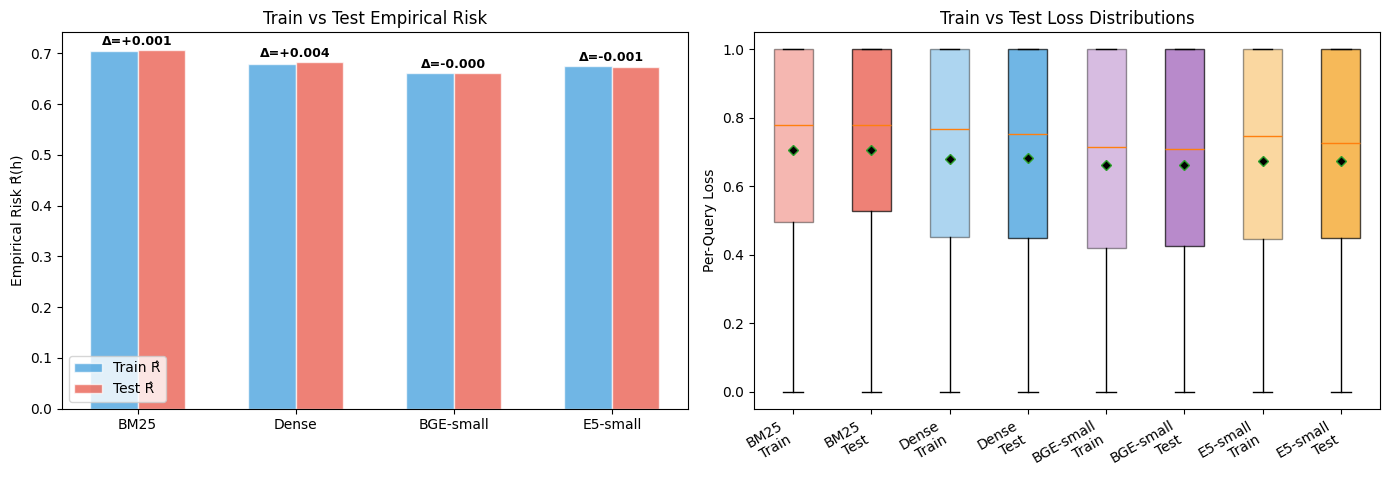

Figure saved.


In [26]:
# ============================================================================
# CELL 28 — Visualize Generalization Gap
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Train vs Test Risk ───────────────────────────────
ax = axes[0]
x_pos = np.arange(len(gap_methods))
width = 0.3

train_risks = [gap_results[n]["R_train"] for n in gap_methods]
test_risks = [gap_results[n]["R_test"] for n in gap_methods]

bars1 = ax.bar(x_pos - width/2, train_risks, width, label="Train R̂",
               color="#3498db", alpha=0.7, edgecolor="white")
bars2 = ax.bar(x_pos + width/2, test_risks, width, label="Test R̂",
               color="#e74c3c", alpha=0.7, edgecolor="white")

# Add gap annotation
for i, name in enumerate(gap_methods):
    gap = gap_results[name]["gap"]
    y_top = max(train_risks[i], test_risks[i])
    ax.annotate(f"Δ={gap:+.3f}", xy=(i, y_top + 0.01),
                ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(x_pos)
ax.set_xticklabels(gap_methods)
ax.set_ylabel("Empirical Risk R̂(h)")
ax.set_title("Train vs Test Empirical Risk")
ax.legend()

# ── Plot 2: Loss distributions for train vs test ────────────
ax = axes[1]
data_for_violin = []
labels_for_violin = []
colors_for_violin = []

for name in gap_methods:
    data_for_violin.append(gap_results[name]["train_losses"])
    labels_for_violin.append(f"{name}\nTrain")
    colors_for_violin.append(COLORS.get(name, "gray"))

    data_for_violin.append(gap_results[name]["test_losses"])
    labels_for_violin.append(f"{name}\nTest")
    colors_for_violin.append(COLORS.get(name, "gray"))

bp = ax.boxplot(data_for_violin, labels=labels_for_violin,
                patch_artist=True, widths=0.5, showmeans=True,
                meanprops=dict(marker="D", markerfacecolor="black", markersize=5))

for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors_for_violin[i])
    patch.set_alpha(0.4 if i % 2 == 0 else 0.7)  # lighter for train

ax.set_ylabel("Per-Query Loss")
ax.set_title("Train vs Test Loss Distributions")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "generalization_gap.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

---
## 7. Head-to-Head Per-Query Comparison

Aggregate metrics can mask important patterns. Here we compare methods
at the per-query level to understand:
- On which queries does BM25 beat Dense? And vice versa?
- Are there systematic patterns in WHERE each method fails?
- Do the methods make correlated or independent errors?

This analysis directly reveals the INDUCTIVE BIAS: each method has
different failure modes.

In [28]:
# ============================================================================
# CELL 30 — Per-Query Head-to-Head Analysis
# ============================================================================

# Compare BM25 vs Dense at the per-query level
common_qids = sorted(
    set(evaluations["BM25"]["per_query_losses"].keys())
    & set(evaluations["Dense"]["per_query_losses"].keys())
)

bm25_losses_paired = np.array([evaluations["BM25"]["per_query_losses"][q] for q in common_qids])
dense_losses_paired = np.array([evaluations["Dense"]["per_query_losses"][q] for q in common_qids])

# Where does each method win?
bm25_wins = np.sum(bm25_losses_paired < dense_losses_paired)
dense_wins = np.sum(dense_losses_paired < bm25_losses_paired)
ties = np.sum(bm25_losses_paired == dense_losses_paired)
loss_diff = bm25_losses_paired - dense_losses_paired  # positive = dense is better

print(f"Head-to-Head: BM25 vs Dense ({len(common_qids)} queries)")
print(f"  BM25 wins:  {bm25_wins} ({bm25_wins/len(common_qids)*100:.1f}%)")
print(f"  Dense wins: {dense_wins} ({dense_wins/len(common_qids)*100:.1f}%)")
print(f"  Ties:       {ties} ({ties/len(common_qids)*100:.1f}%)")

# Paired statistical test
stat, p_paired = stats.wilcoxon(bm25_losses_paired, dense_losses_paired)
print(f"\n  Wilcoxon signed-rank test:")
print(f"    statistic = {stat:.1f}, p-value = {p_paired:.4f}")
print(f"    {'Significant' if p_paired < 0.05 else 'Not significant'} difference (α=0.05)")

# Correlation between methods
corr, p_corr = stats.pearsonr(bm25_losses_paired, dense_losses_paired)
print(f"\n  Loss correlation: r = {corr:.3f} (p = {p_corr:.4f})")
print(f"    {'High' if corr > 0.5 else 'Low'} correlation → ",
      f"{'similar' if corr > 0.5 else 'different'} failure modes")

Head-to-Head: BM25 vs Dense (323 queries)
  BM25 wins:  96 (29.7%)
  Dense wins: 119 (36.8%)
  Ties:       108 (33.4%)

  Wilcoxon signed-rank test:
    statistic = 9901.5, p-value = 0.0614
    Not significant difference (α=0.05)

  Loss correlation: r = 0.765 (p = 0.0000)
    High correlation →  similar failure modes


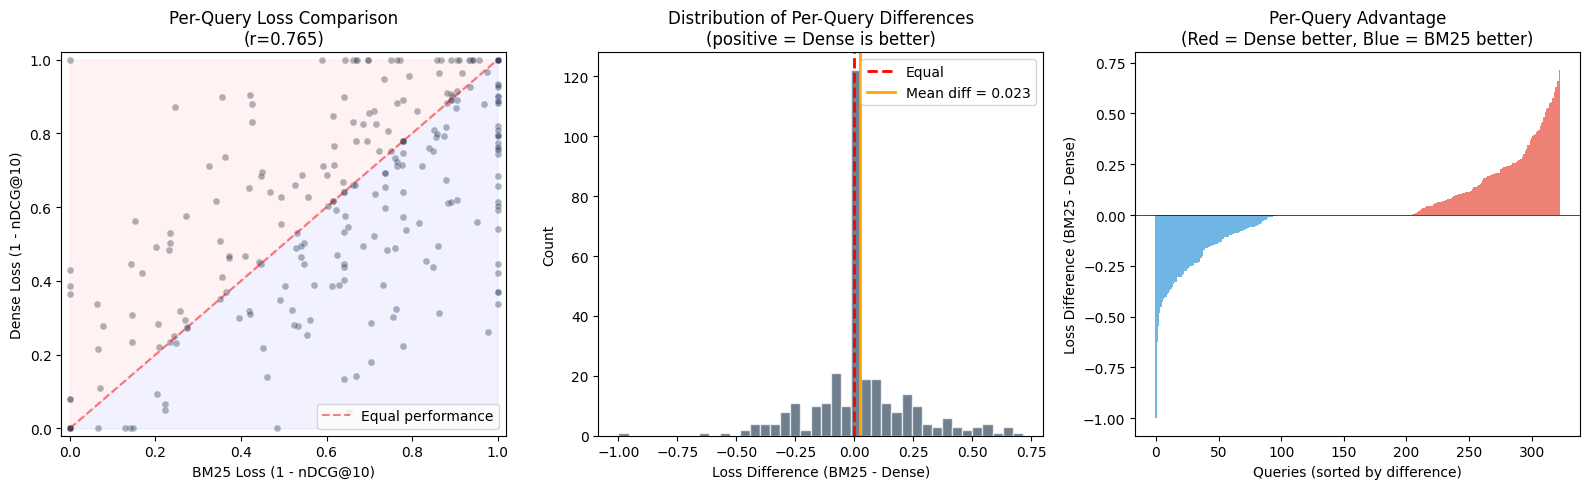

Figure saved.

  Paired bootstrap (10,000 resamples) — mean(BM25 loss − Dense loss):
    Observed mean   : +0.0233
    95% CI          : [-0.0004, +0.0462]
    → CI straddles 0: difference is not significant at 95%.

  Bootstrap CI vs. Wilcoxon:
    • Wilcoxon: tests whether the median signed rank differs from 0.
    • Bootstrap CI: directly quantifies the mean nDCG@10 gap with
      uncertainty bounds — an effect-size measure the Wilcoxon lacks.
      This is the standard in modern IR evaluation (TREC, CLEF, etc.).


In [29]:
# ============================================================================
# CELL 31 — Visualize Per-Query Comparison
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Scatter — BM25 loss vs Dense loss per query ─────
ax = axes[0]
ax.scatter(bm25_losses_paired, dense_losses_paired, alpha=0.4, s=25,
           color="#34495e", edgecolors="white", linewidth=0.5)
ax.plot([0, 1], [0, 1], "r--", alpha=0.5, label="Equal performance")
ax.set_xlabel("BM25 Loss (1 - nDCG@10)")
ax.set_ylabel("Dense Loss (1 - nDCG@10)")
ax.set_title(f"Per-Query Loss Comparison\n(r={corr:.3f})")
ax.legend()
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)

# Color the regions
ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.05, color="blue",
                label="Dense better")
ax.fill_between([0, 1], [0, 1], [1, 1], alpha=0.05, color="red",
                label="BM25 better")

# ── Plot 2: Histogram of loss differences ───────────────────
ax = axes[1]
ax.hist(loss_diff, bins=40, color="#34495e", alpha=0.7, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", linewidth=2, label="Equal")
ax.axvline(np.mean(loss_diff), color="orange", linestyle="-", linewidth=2,
           label=f"Mean diff = {np.mean(loss_diff):.3f}")
ax.set_xlabel("Loss Difference (BM25 - Dense)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Per-Query Differences\n(positive = Dense is better)")
ax.legend()

# ── Plot 3: Queries sorted by difference ────────────────────
ax = axes[2]
sorted_diff = np.sort(loss_diff)
x = np.arange(len(sorted_diff))
colors_bar = ["#e74c3c" if d > 0 else "#3498db" for d in sorted_diff]
ax.bar(x, sorted_diff, color=colors_bar, width=1.0, alpha=0.7)
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Queries (sorted by difference)")
ax.set_ylabel("Loss Difference (BM25 - Dense)")
ax.set_title("Per-Query Advantage\n(Red = Dense better, Blue = BM25 better)")

plt.tight_layout()
plt.savefig(os.path.join(CONFIG["results_dir"], "per_query_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")

# ── Paired bootstrap confidence intervals ──────────────────────────────────
# Bootstrap CI directly estimates the *mean* loss difference and its precision,
# which is the quantity that matters when comparing expected retrieval quality.
# Wilcoxon tests the *median rank-sum*: useful for null-hypothesis testing but
# provides no effect-size interval.
_n_bs = CONFIG["n_bootstrap"]
_rng_bs = np.random.default_rng(SEED)
_boot_mean_diffs = np.array(
    [np.mean(loss_diff[_rng_bs.integers(0, len(common_qids), size=len(common_qids))])
     for _ in range(_n_bs)]
)
_ci_lo, _ci_hi = np.percentile(_boot_mean_diffs, [2.5, 97.5])
_obs_mean = np.mean(loss_diff)

print(f"\n  Paired bootstrap ({_n_bs:,} resamples) — mean(BM25 loss − Dense loss):")
print(f"    Observed mean   : {_obs_mean:+.4f}")
print(f"    95% CI          : [{_ci_lo:+.4f}, {_ci_hi:+.4f}]")
if _ci_lo > 0:
    print("    → CI entirely above 0: Dense is significantly better (α=0.05).")
elif _ci_hi < 0:
    print("    → CI entirely below 0: BM25 is significantly better (α=0.05).")
else:
    print("    → CI straddles 0: difference is not significant at 95%.")
print()
print("  Bootstrap CI vs. Wilcoxon:")
print("    • Wilcoxon: tests whether the median signed rank differs from 0.")
print("    • Bootstrap CI: directly quantifies the mean nDCG@10 gap with")
print("      uncertainty bounds — an effect-size measure the Wilcoxon lacks.")
print("      This is the standard in modern IR evaluation (TREC, CLEF, etc.).")


In [30]:
# ============================================================================
# CELL 32 — Identify Characteristic Failure Queries
# ============================================================================

# Find queries where BM25 greatly outperforms Dense (and vice versa)
# These reveal the specific inductive bias limitations

THRESHOLD = 0.3  # loss difference threshold

print("=" * 70)
print("  Queries Revealing Inductive Bias Differences")
print("=" * 70)

# Queries where BM25 >> Dense (BM25 loss much lower)
bm25_advantage = [(common_qids[i], loss_diff[i]) for i in range(len(common_qids))
                  if loss_diff[i] < -THRESHOLD]
bm25_advantage.sort(key=lambda x: x[1])

print(f"\n  Queries where BM25 >> Dense ({len(bm25_advantage)} queries):")
print(f"  (Dense's semantic bias FAILS here — exact matching needed)")
for qid, diff in bm25_advantage[:5]:
    query = test_queries[qid]
    bm25_l = evaluations["BM25"]["per_query_losses"][qid]
    dense_l = evaluations["Dense"]["per_query_losses"][qid]
    print(f"    [{qid}] BM25 loss={bm25_l:.3f}, Dense loss={dense_l:.3f}, Δ={diff:.3f}")
    print(f"      Query: \"{query}\"")

# Queries where Dense >> BM25
dense_advantage = [(common_qids[i], loss_diff[i]) for i in range(len(common_qids))
                   if loss_diff[i] > THRESHOLD]
dense_advantage.sort(key=lambda x: -x[1])

print(f"\n  Queries where Dense >> BM25 ({len(dense_advantage)} queries):")
print(f"  (BM25's lexical bias FAILS here — semantic understanding needed)")
for qid, diff in dense_advantage[:5]:
    query = test_queries[qid]
    bm25_l = evaluations["BM25"]["per_query_losses"][qid]
    dense_l = evaluations["Dense"]["per_query_losses"][qid]
    print(f"    [{qid}] BM25 loss={bm25_l:.3f}, Dense loss={dense_l:.3f}, Δ={diff:+.3f}")
    print(f"      Query: \"{query}\"")

print("\n" + "=" * 70)

  Queries Revealing Inductive Bias Differences

  Queries where BM25 >> Dense (21 queries):
  (Dense's semantic bias FAILS here — exact matching needed)
    [PLAIN-1473] BM25 loss=0.000, Dense loss=1.000, Δ=-1.000
      Query: "kohlrabi"
    [PLAIN-1288] BM25 loss=0.247, Dense loss=0.870, Δ=-0.624
      Query: "grapes"
    [PLAIN-792] BM25 loss=0.355, Dense loss=0.899, Δ=-0.544
      Query: "cadaverine"
    [PLAIN-2490] BM25 loss=0.420, Dense loss=0.904, Δ=-0.484
      Query: "The Actual Benefit of Diet vs. Drugs"
    [PLAIN-3452] BM25 loss=0.425, Dense loss=0.879, Δ=-0.454
      Query: "Bowel Movement Frequency"

  Queries where Dense >> BM25 (29 queries):
  (BM25's lexical bias FAILS here — semantic understanding needed)
    [PLAIN-2730] BM25 loss=0.977, Dense loss=0.261, Δ=+0.716
      Query: "Anti-Angiogenesis: Cutting Off Tumor Supply Lines"
    [PLAIN-1537] BM25 loss=1.000, Dense loss=0.338, Δ=+0.662
      Query: "low-carb diets"
    [PLAIN-681] BM25 loss=1.000, Dense loss=0.369,


## Additional experiments for the next submission

This section adds the experiments that the baseline report proposed, plus one stronger stability check that directly matches the research question.

What gets added here:
1. **Split-level retrieval with caching** for train/dev/test.
2. **Hybrid retrieval** with dev-tuned score fusion and an RRF baseline.
3. **Synonym perturbation** to test stability under small query edits.
4. **Vocabulary-gap analysis** to connect lexical matchability to retrieval quality.
5. **Query stratification** by a technicality proxy and by estimated vocabulary gap.
6. **Repeated query-subset evaluation** to measure how much the Dense-vs-BM25 advantage depends on which queries are sampled.
7. **Failure analysis exports** for report tables and qualitative examples.

> Recommended order: run the baseline notebook first through the evaluation section, then run the cells below in order.


In [31]:

# ============================================================================
# NEW SECTION — Additional Experiments for the Next Submission
# Run all baseline cells above first so that BM25, Dense, corpus, queries, qrels,
# and evaluate_retriever(...) are already available in memory.
# ============================================================================

import os
import re
import json
import math
import pickle
import random
from pathlib import Path
from collections import defaultdict, Counter

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm
from IPython.display import display

# Keep all new experiment artifacts in a separate directory
NEXT_STAGE_CONFIG = {
    "random_seed": 42,
    "top_k_retrieve": TOP_K_RETRIEVE,
    "top_k_overlap": 10,
    "synonym_max_replacements": 1,
    "hybrid_alpha_grid": np.linspace(0.0, 1.0, 11),
    "rrf_k": 60,
    "query_subset_trials": 2000,
    "subset_size": len(test_queries),
}

EXPERIMENT_DIR = os.path.join(CONFIG["results_dir"], "next_stage")
CACHE_DIR = os.path.join(EXPERIMENT_DIR, "cache")
TABLE_DIR = os.path.join(EXPERIMENT_DIR, "tables")
FIG_DIR = os.path.join(EXPERIMENT_DIR, "figures")

for path in [EXPERIMENT_DIR, CACHE_DIR, TABLE_DIR, FIG_DIR]:
    os.makedirs(path, exist_ok=True)

random.seed(NEXT_STAGE_CONFIG["random_seed"])
np.random.seed(NEXT_STAGE_CONFIG["random_seed"])

# Reuse already-computed test retrievals from the baseline section
experiment_results = {
    "BM25": bm25_results,
    "Dense": dense_results,
}
experiment_evaluations = {
    "BM25": evaluations["BM25"],
    "Dense": evaluations["Dense"],
}

# -----------------------------
# Utility helpers
# -----------------------------
def save_pickle(obj, path: str) -> None:
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)


def cache_or_compute(path: str, compute_fn, force: bool = False, verbose: bool = True):
    if os.path.exists(path) and not force:
        if verbose:
            print(f"Loaded cache: {path}")
        return load_pickle(path)

    value = compute_fn()
    save_pickle(value, path)
    if verbose:
        print(f"Saved cache: {path}")
    return value


def ensure_nltk_resource(resource_name: str, lookup_path: str) -> None:
    try:
        nltk.data.find(lookup_path)
    except LookupError:
        nltk.download(resource_name, quiet=True)


def dense_retrieve_batch_chunked(
    queries: dict,
    top_k: int = 100,
    chunk_size: int = 128,
) -> dict:
    """
    Chunked wrapper around dense_retrieve_batch to keep long runs stable and cacheable.
    """
    qids = list(queries.keys())
    results = {}

    for start in tqdm(range(0, len(qids), chunk_size), desc="Dense chunks"):
        batch_qids = qids[start:start + chunk_size]
        batch_queries = {qid: queries[qid] for qid in batch_qids}
        batch_results = dense_retrieve_batch(batch_queries, top_k=top_k)
        results.update(batch_results)

    return results


def sorted_doc_ids(result_dict: dict, top_k: int = 10) -> list:
    return [
        doc_id
        for doc_id, _ in sorted(result_dict.items(), key=lambda x: -x[1])[:top_k]
    ]


def display_metric_table(eval_dict: dict, metric_names: list, title: str = "Metrics"):
    rows = []
    for method_name, eval_obj in eval_dict.items():
        row = {"method": method_name}
        for metric in metric_names:
            row[metric] = eval_obj["aggregate"].get(metric, np.nan)
        rows.append(row)

    df = pd.DataFrame(rows)
    print(f"\n{title}")
    display(df.round(4))
    return df


def get_per_query_metric(eval_obj: dict, metric_name: str = "nDCG@10") -> dict:
    return {qid: metrics[metric_name] for qid, metrics in eval_obj["per_query"].items()}


def export_dataframe(df: pd.DataFrame, filename: str) -> str:
    path = os.path.join(TABLE_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")
    return path


def make_quantile_bins(series: pd.Series, labels: list) -> pd.Series:
    """
    Robust quantile binning even when the raw values contain ties.
    """
    ranked = series.rank(method="first")
    return pd.qcut(ranked, q=len(labels), labels=labels)


def mean_ci(values, alpha: float = 0.05):
    values = np.asarray(values, dtype=float)
    mean = values.mean()
    lo = np.quantile(values, alpha / 2)
    hi = np.quantile(values, 1 - alpha / 2)
    return mean, lo, hi


print("✓ Next-stage experiment helpers are ready.")


✓ Next-stage experiment helpers are ready.


In [32]:
# ============================================================================
# MEMORY CHECK — run this before the experiments below
# If available memory is below ~2GB, restart kernel and re-run baseline cells
# ============================================================================
import psutil, gc

gc.collect()
mem = psutil.virtual_memory()
print(f'Total RAM      : {mem.total / 1e9:.1f} GB')
print(f'Available RAM  : {mem.available / 1e9:.1f} GB')
print(f'Used RAM       : {mem.used / 1e9:.1f} GB  ({mem.percent:.1f}%)')

if mem.available < 2e9:
    print('\n⚠️  WARNING: Less than 2GB available.')
    print('   Restart the kernel, run baseline cells only, then continue here.')
else:
    print('\n✓ Memory looks OK to proceed.')


Total RAM      : 25.8 GB
Available RAM  : 9.9 GB
Used RAM       : 12.5 GB  (61.8%)

✓ Memory looks OK to proceed.


In [33]:

# ============================================================================
# NEW CELL — Retrieve and evaluate train / dev / test splits with caching
# ============================================================================

split_queries = {
    "train": train_queries,
    "dev": dev_queries,
    "test": test_queries,
}
split_qrels = {
    "train": train_qrels,
    "dev": dev_qrels,
    "test": test_qrels,
}

split_retrievals = {}
for split_name, query_dict in split_queries.items():
    print(f"\nRetrieving split: {split_name} ({len(query_dict)} queries)")

    if split_name == "test":
        # Reuse the baseline run rather than recomputing it
        bm25_split = experiment_results["BM25"]
        dense_split = experiment_results["Dense"]
    else:
        bm25_cache = os.path.join(CACHE_DIR, f"{split_name}_bm25_results.pkl")
        dense_cache = os.path.join(CACHE_DIR, f"{split_name}_dense_results.pkl")

        bm25_split = cache_or_compute(
            bm25_cache,
            lambda q=query_dict: bm25_retrieve_batch(
                q, top_k=NEXT_STAGE_CONFIG["top_k_retrieve"]
            ),
        )
        dense_split = cache_or_compute(
            dense_cache,
            lambda q=query_dict: dense_retrieve_batch_chunked(
                q,
                top_k=NEXT_STAGE_CONFIG["top_k_retrieve"],
                chunk_size=64,  # safe chunk size for 2590-query train split
            ),
        )

    split_retrievals[split_name] = {
        "BM25": bm25_split,
        "Dense": dense_split,
    }

split_evaluations = {}
for split_name in split_queries:
    split_evaluations[split_name] = {}
    for method_name, results_obj in split_retrievals[split_name].items():
        split_evaluations[split_name][method_name] = evaluate_retriever(
            results_obj,
            split_qrels[split_name],
        )

split_rows = []
for split_name, per_method in split_evaluations.items():
    for method_name, eval_obj in per_method.items():
        agg = eval_obj["aggregate"]
        split_rows.append(
            {
                "split": split_name,
                "method": method_name,
                "n_queries": agg["n_queries"],
                "nDCG@10": agg["nDCG@10"],
                "Recall@10": agg["Recall@10"],
                "P@10": agg["P@10"],
                "empirical_risk": agg["empirical_risk"],
                "loss_variance": agg["loss_variance"],
            }
        )

split_metrics_df = pd.DataFrame(split_rows).sort_values(["split", "method"]).reset_index(drop=True)
display(split_metrics_df.round(4))
export_dataframe(split_metrics_df, "split_metrics_baselines.csv")



Retrieving split: train (2590 queries)
Loaded cache: results/next_stage/cache/train_bm25_results.pkl
Loaded cache: results/next_stage/cache/train_dense_results.pkl



Retrieving split: dev (324 queries)
Loaded cache: results/next_stage/cache/dev_bm25_results.pkl
Loaded cache: results/next_stage/cache/dev_dense_results.pkl

Retrieving split: test (323 queries)


,split,method,n_queries,nDCG@10,Recall@10,P@10,empirical_risk,loss_variance
0,dev,BM25,324,0.2640,0.1055,0.2068,0.7360,0.0826
1,dev,Dense,324,0.3026,0.1364,0.2401,0.6974,0.0898
2,test,BM25,323,0.2940,0.1373,0.2074,0.7060,0.0967
3,test,Dense,323,0.3173,0.1550,0.2433,0.6827,0.0970
4,train,BM25,2590,0.2953,0.1284,0.2174,0.7047,0.0920
5,train,Dense,2590,0.3208,0.1428,0.2488,0.6792,0.0983


Saved table: results/next_stage/tables/split_metrics_baselines.csv


'results/next_stage/tables/split_metrics_baselines.csv'


## Hybrid retrieval

This experiment tests whether BM25 and Dense are complementary rather than purely competing.

- **Tuning rule:** choose the BM25 weight \(\alpha\) on the **dev** split only.
- **Main hybrid:** min-max normalized linear score fusion.
- **Robust baseline:** Reciprocal Rank Fusion (RRF).

This is useful for the report because it shows whether combining two different inductive biases improves average performance and/or reduces variance.


Best dev alpha for linear fusion: 0.40


,alpha,nDCG@10,Recall@10,P@10,empirical_risk
0,0.0,0.3024,0.1364,0.2401,0.6976
1,0.1,0.3081,0.1379,0.2441,0.6919
2,0.2,0.3132,0.1390,0.2475,0.6868
3,0.3,0.3180,0.1409,0.2515,0.6820
4,0.4,0.3210,0.1432,0.2543,0.6790
5,0.5,0.3150,0.1398,0.2537,0.6850
6,0.6,0.3102,0.1373,0.2478,0.6898
7,0.7,0.3038,0.1334,0.2410,0.6962
8,0.8,0.2934,0.1281,0.2299,0.7066
9,0.9,0.2838,0.1250,0.2210,0.7162


Saved table: results/next_stage/tables/hybrid_alpha_sweep_dev.csv


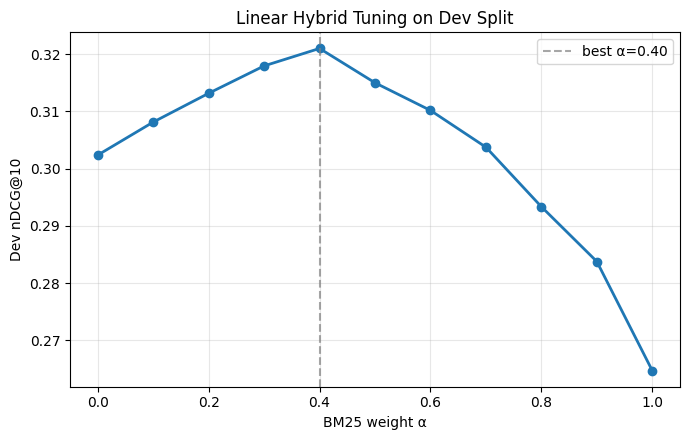

,method,nDCG@10,Recall@10,P@10,empirical_risk,loss_variance
0,BM25,0.2940,0.1373,0.2074,0.7060,0.0967
1,Dense,0.3173,0.1550,0.2433,0.6827,0.0970
2,Hybrid,0.3380,0.1641,0.2542,0.6620,0.1015
3,RRF(k=60),0.3235,0.1540,0.2396,0.6765,0.0991


Saved table: results/next_stage/tables/hybrid_test_comparison.csv


,split,method,n_queries,nDCG@10,Recall@10,P@10,empirical_risk,loss_variance
0,dev,BM25,324,0.2640,0.1055,0.2068,0.7360,0.0826
1,dev,Dense,324,0.3026,0.1364,0.2401,0.6974,0.0898
2,dev,Hybrid,324,0.3210,0.1432,0.2543,0.6790,0.0921
3,test,BM25,323,0.2940,0.1373,0.2074,0.7060,0.0967
4,test,Dense,323,0.3173,0.1550,0.2433,0.6827,0.0970
5,test,Hybrid,323,0.3380,0.1641,0.2542,0.6620,0.1015
6,train,BM25,2590,0.2953,0.1284,0.2174,0.7047,0.0920
7,train,Dense,2590,0.3208,0.1428,0.2488,0.6792,0.0983
8,train,Hybrid,2590,0.3446,0.1587,0.2632,0.6554,0.0994


Saved table: results/next_stage/tables/split_metrics_with_hybrid.csv


'results/next_stage/tables/split_metrics_with_hybrid.csv'

In [34]:

# ============================================================================
# NEW CELL — Hybrid retrieval: dev-tuned score fusion + RRF baseline
# ============================================================================

def normalize_scores(score_dict: dict, mode: str = "minmax") -> dict:
    """
    Normalize per-query scores before linear fusion.
    """
    if not score_dict:
        return {}

    docs = list(score_dict.keys())
    values = np.array([score_dict[d] for d in docs], dtype=float)

    if mode == "minmax":
        lo, hi = values.min(), values.max()
        if np.isclose(lo, hi):
            norm_values = np.ones_like(values)
        else:
            norm_values = (values - lo) / (hi - lo)
    elif mode == "zscore":
        mean = values.mean()
        std = values.std()
        if np.isclose(std, 0.0):
            norm_values = np.zeros_like(values)
        else:
            norm_values = (values - mean) / std
    else:
        raise ValueError(f"Unknown normalization mode: {mode}")

    return {doc: float(val) for doc, val in zip(docs, norm_values)}


def linear_fuse_results(
    results_a: dict,
    results_b: dict,
    alpha: float = 0.5,
    norm: str = "minmax",
    top_k: int = 100,
) -> dict:
    """
    Query-wise linear score fusion:
        fused = alpha * normalized(BM25) + (1 - alpha) * normalized(Dense)
    """
    fused = {}
    common_qids = sorted(set(results_a) & set(results_b))

    for qid in common_qids:
        a_norm = normalize_scores(results_a[qid], mode=norm)
        b_norm = normalize_scores(results_b[qid], mode=norm)

        all_doc_ids = set(a_norm) | set(b_norm)
        fused_scores = {}
        for doc_id in all_doc_ids:
            fused_scores[doc_id] = alpha * a_norm.get(doc_id, 0.0) + (1.0 - alpha) * b_norm.get(doc_id, 0.0)

        ranked = sorted(fused_scores.items(), key=lambda x: -x[1])[:top_k]
        fused[qid] = {doc_id: float(score) for doc_id, score in ranked}

    return fused


def rrf_fuse_results(
    results_a: dict,
    results_b: dict,
    rrf_k: int = 60,
    top_k: int = 100,
) -> dict:
    """
    Reciprocal Rank Fusion (robust score-free hybrid baseline).
    """
    fused = {}
    common_qids = sorted(set(results_a) & set(results_b))

    for qid in common_qids:
        scores = defaultdict(float)

        for source in [results_a[qid], results_b[qid]]:
            ranked_docs = sorted(source.items(), key=lambda x: -x[1])
            for rank_idx, (doc_id, _) in enumerate(ranked_docs, start=1):
                scores[doc_id] += 1.0 / (rrf_k + rank_idx)

        ranked = sorted(scores.items(), key=lambda x: -x[1])[:top_k]
        fused[qid] = {doc_id: float(score) for doc_id, score in ranked}

    return fused


# ---- Tune alpha on dev only (no test leakage) ----
hybrid_dev_rows = []
for alpha in NEXT_STAGE_CONFIG["hybrid_alpha_grid"]:
    fused_dev = linear_fuse_results(
        split_retrievals["dev"]["BM25"],
        split_retrievals["dev"]["Dense"],
        alpha=float(alpha),
        norm="minmax",
        top_k=NEXT_STAGE_CONFIG["top_k_retrieve"],
    )
    dev_eval = evaluate_retriever(fused_dev, dev_qrels)
    hybrid_dev_rows.append(
        {
            "alpha": float(alpha),
            "nDCG@10": dev_eval["aggregate"]["nDCG@10"],
            "Recall@10": dev_eval["aggregate"]["Recall@10"],
            "P@10": dev_eval["aggregate"]["P@10"],
            "empirical_risk": dev_eval["aggregate"]["empirical_risk"],
        }
    )

hybrid_dev_df = pd.DataFrame(hybrid_dev_rows).sort_values("alpha").reset_index(drop=True)
best_alpha = float(
    hybrid_dev_df.sort_values(
        ["nDCG@10", "Recall@10", "P@10"],
        ascending=False,
    ).iloc[0]["alpha"]
)

print(f"Best dev alpha for linear fusion: {best_alpha:.2f}")
display(hybrid_dev_df.round(4))
export_dataframe(hybrid_dev_df, "hybrid_alpha_sweep_dev.csv")

# ---- Evaluate the selected linear hybrid on all splits ----
for split_name in split_queries:
    fused_split = linear_fuse_results(
        split_retrievals[split_name]["BM25"],
        split_retrievals[split_name]["Dense"],
        alpha=best_alpha,
        norm="minmax",
        top_k=NEXT_STAGE_CONFIG["top_k_retrieve"],
    )
    split_retrievals[split_name]["Hybrid"] = fused_split
    split_evaluations[split_name]["Hybrid"] = evaluate_retriever(
        fused_split,
        split_qrels[split_name],
    )

# Reuse test hybrid in the main experiment dict
experiment_results["Hybrid"] = split_retrievals["test"]["Hybrid"]
experiment_evaluations["Hybrid"] = split_evaluations["test"]["Hybrid"]

# ---- Optional: compare with RRF on test ----
rrf_test_results = rrf_fuse_results(
    experiment_results["BM25"],
    experiment_results["Dense"],
    rrf_k=NEXT_STAGE_CONFIG["rrf_k"],
    top_k=NEXT_STAGE_CONFIG["top_k_retrieve"],
)
rrf_test_eval = evaluate_retriever(rrf_test_results, test_qrels)

# ---- Plot alpha sweep on dev ----
plt.figure(figsize=(7, 4.5))
plt.plot(hybrid_dev_df["alpha"], hybrid_dev_df["nDCG@10"], marker="o", linewidth=2)
plt.axvline(best_alpha, linestyle="--", color="gray", alpha=0.7, label=f"best α={best_alpha:.2f}")
plt.xlabel("BM25 weight α")
plt.ylabel("Dev nDCG@10")
plt.title("Linear Hybrid Tuning on Dev Split")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "hybrid_alpha_sweep_dev.png"), dpi=150, bbox_inches="tight")
plt.show()

# ---- Summary comparison on test ----
hybrid_compare_rows = []
for method_name in ["BM25", "Dense", "Hybrid"]:
    agg = experiment_evaluations[method_name]["aggregate"]
    hybrid_compare_rows.append(
        {
            "method": method_name,
            "nDCG@10": agg["nDCG@10"],
            "Recall@10": agg["Recall@10"],
            "P@10": agg["P@10"],
            "empirical_risk": agg["empirical_risk"],
            "loss_variance": agg["loss_variance"],
        }
    )

hybrid_compare_rows.append(
    {
        "method": f"RRF(k={NEXT_STAGE_CONFIG['rrf_k']})",
        "nDCG@10": rrf_test_eval["aggregate"]["nDCG@10"],
        "Recall@10": rrf_test_eval["aggregate"]["Recall@10"],
        "P@10": rrf_test_eval["aggregate"]["P@10"],
        "empirical_risk": rrf_test_eval["aggregate"]["empirical_risk"],
        "loss_variance": rrf_test_eval["aggregate"]["loss_variance"],
    }
)

hybrid_test_df = pd.DataFrame(hybrid_compare_rows)
display(hybrid_test_df.round(4))
export_dataframe(hybrid_test_df, "hybrid_test_comparison.csv")


# ---- Updated split-level metrics including Hybrid ----
updated_split_rows = []
for split_name, per_method in split_evaluations.items():
    for method_name, eval_obj in per_method.items():
        agg = eval_obj["aggregate"]
        updated_split_rows.append(
            {
                "split": split_name,
                "method": method_name,
                "n_queries": agg["n_queries"],
                "nDCG@10": agg["nDCG@10"],
                "Recall@10": agg["Recall@10"],
                "P@10": agg["P@10"],
                "empirical_risk": agg["empirical_risk"],
                "loss_variance": agg["loss_variance"],
            }
        )

split_metrics_with_hybrid_df = pd.DataFrame(updated_split_rows).sort_values(["split", "method"]).reset_index(drop=True)
display(split_metrics_with_hybrid_df.round(4))
export_dataframe(split_metrics_with_hybrid_df, "split_metrics_with_hybrid.csv")


Loaded cache: results/next_stage/cache/doc_token_sets.pkl
Saved table: results/next_stage/tables/vocabulary_gap_features.csv


,relationship,spearman_rho,p_value
0,BM25: retrieved lexical overlap vs nDCG@10,0.3750,0.0000
1,Dense: retrieved lexical overlap vs nDCG@10,0.4351,0.0000
2,Hybrid: retrieved lexical overlap vs nDCG@10,0.4124,0.0000
3,oracle lexical overlap vs (Dense - BM25) nDCG@10,-0.1992,0.0003


Saved table: results/next_stage/tables/vocabulary_gap_correlations.csv


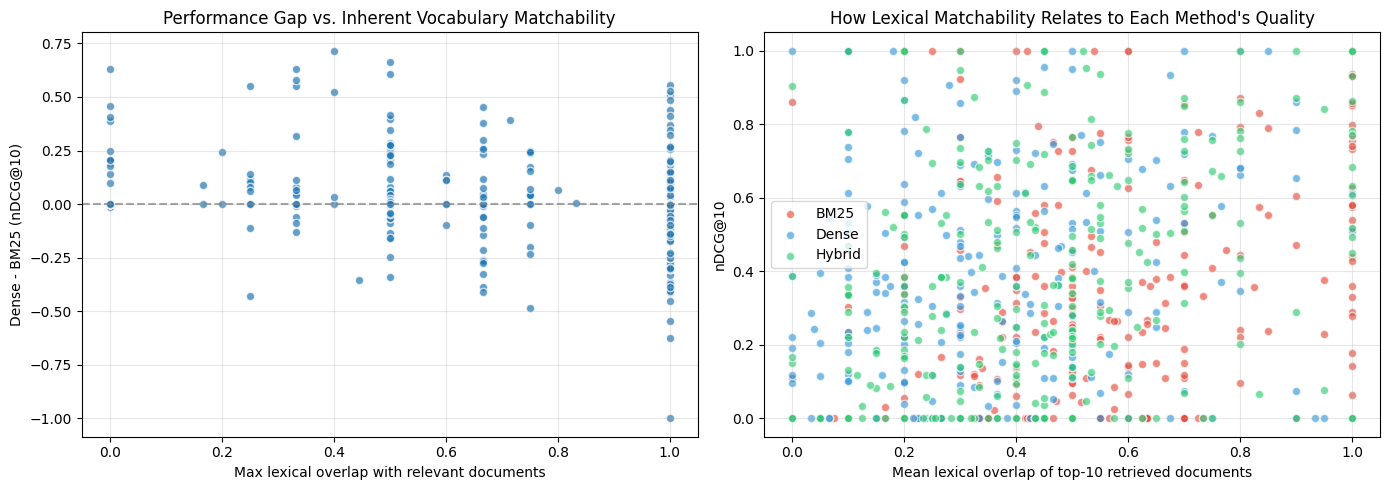

In [36]:
import re
from nltk.corpus import stopwords as _stopwords_corpus

# TOKEN_PATTERN and STOPWORDS were defined in the (now-disabled) synonym cell.
# Re-defining them here so the vocabulary-gap analysis runs standalone.
TOKEN_PATTERN = re.compile(r'^[A-Za-z][A-Za-z\-]*$')
try:
    STOPWORDS = set(_stopwords_corpus.words('english'))
except LookupError:
    import nltk as _nltk_sw
    _nltk_sw.download('stopwords', quiet=True)
    STOPWORDS = set(_stopwords_corpus.words('english'))


# ============================================================================
# NEW CELL — Vocabulary-gap analysis
# ============================================================================

def content_tokens(text: str) -> list:
    tokens = [tok.lower() for tok in nltk.word_tokenize(text)]
    return [
        tok
        for tok in tokens
        if TOKEN_PATTERN.match(tok) and tok not in STOPWORDS and len(tok) >= 3
    ]


doc_token_cache = os.path.join(CACHE_DIR, "doc_token_sets.pkl")
doc_token_sets = cache_or_compute(
    doc_token_cache,
    lambda: {
        did: set(content_tokens(
            (corpus[did].get("title", "") + " " + corpus[did].get("text", "")).strip()
        ))
        for did in doc_ids
    },
)

idf_values = list(bm25_idf.values())
default_query_idf = float(np.median(idf_values)) if idf_values else 0.0


def query_doc_overlap(query_text: str, doc_id: str) -> float:
    q_tokens = set(content_tokens(query_text))
    if not q_tokens:
        return 0.0
    d_tokens = doc_token_sets.get(doc_id, set())
    return len(q_tokens & d_tokens) / len(q_tokens)


def ranking_mean_overlap(query_text: str, result_dict: dict, top_k: int = 10) -> float:
    ranked_doc_ids = sorted_doc_ids(result_dict, top_k=top_k)
    if not ranked_doc_ids:
        return 0.0
    overlaps = [query_doc_overlap(query_text, did) for did in ranked_doc_ids]
    return float(np.mean(overlaps))


def oracle_relevant_overlap(query_text: str, qrel_dict: dict, reduce: str = "max") -> float:
    relevant_doc_ids = list(qrel_dict.keys())
    overlaps = [query_doc_overlap(query_text, did) for did in relevant_doc_ids]
    if not overlaps:
        return 0.0
    if reduce == "max":
        return float(np.max(overlaps))
    if reduce == "mean":
        return float(np.mean(overlaps))
    raise ValueError("reduce must be 'max' or 'mean'")


def query_technicality_score(query_text: str) -> float:
    q_tokens = content_tokens(query_text)
    if not q_tokens:
        return 0.0
    idfs = [bm25_idf.get(tok, default_query_idf) for tok in q_tokens]
    return float(np.mean(idfs))


vocab_rows = []
for qid, query_text in test_queries.items():
    row = {
        "qid": qid,
        "query": query_text,
        "n_content_tokens": len(set(content_tokens(query_text))),
        "oracle_max_overlap": oracle_relevant_overlap(query_text, test_qrels[qid], reduce="max"),
        "oracle_mean_overlap": oracle_relevant_overlap(query_text, test_qrels[qid], reduce="mean"),
        "technicality_score": query_technicality_score(query_text),
    }
    row["vocab_gap_score"] = 1.0 - row["oracle_max_overlap"]

    for method_name, result_obj in experiment_results.items():
        row[f"{method_name}_retrieved_overlap"] = ranking_mean_overlap(
            query_text,
            result_obj[qid],
            top_k=NEXT_STAGE_CONFIG["top_k_overlap"],
        )
        row[f"{method_name}_nDCG@10"] = experiment_evaluations[method_name]["per_query"][qid]["nDCG@10"]
        row[f"{method_name}_Recall@10"] = experiment_evaluations[method_name]["per_query"][qid]["Recall@10"]

    row["Dense_minus_BM25"] = row["Dense_nDCG@10"] - row["BM25_nDCG@10"]
    if "Hybrid_nDCG@10" in row:
        row["Hybrid_minus_Dense"] = row["Hybrid_nDCG@10"] - row["Dense_nDCG@10"]

    vocab_rows.append(row)

vocab_gap_df = pd.DataFrame(vocab_rows)
export_dataframe(vocab_gap_df, "vocabulary_gap_features.csv")

# ---- Correlation summary ----
corr_rows = []
for method_name in experiment_results.keys():
    rho_overlap, p_overlap = stats.spearmanr(
        vocab_gap_df[f"{method_name}_retrieved_overlap"],
        vocab_gap_df[f"{method_name}_nDCG@10"],
    )
    corr_rows.append(
        {
            "relationship": f"{method_name}: retrieved lexical overlap vs nDCG@10",
            "spearman_rho": rho_overlap,
            "p_value": p_overlap,
        }
    )

rho_gap, p_gap = stats.spearmanr(vocab_gap_df["oracle_max_overlap"], vocab_gap_df["Dense_minus_BM25"])
corr_rows.append(
    {
        "relationship": "oracle lexical overlap vs (Dense - BM25) nDCG@10",
        "spearman_rho": rho_gap,
        "p_value": p_gap,
    }
)

corr_df = pd.DataFrame(corr_rows)
display(corr_df.round(4))
export_dataframe(corr_df, "vocabulary_gap_correlations.csv")

# ---- Plot overlap-performance relationships ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) Does Dense gain more when oracle lexical overlap is low?
axes[0].scatter(
    vocab_gap_df["oracle_max_overlap"],
    vocab_gap_df["Dense_minus_BM25"],
    alpha=0.7,
    edgecolors="white",
)
axes[0].axhline(0.0, linestyle="--", color="gray", alpha=0.7)
axes[0].set_xlabel("Max lexical overlap with relevant documents")
axes[0].set_ylabel("Dense - BM25 (nDCG@10)")
axes[0].set_title("Performance Gap vs. Inherent Vocabulary Matchability")
axes[0].grid(alpha=0.3)

# (2) Retrieved overlap vs own performance
axes[1].scatter(
    vocab_gap_df["BM25_retrieved_overlap"],
    vocab_gap_df["BM25_nDCG@10"],
    alpha=0.65,
    label="BM25",
    color=COLORS.get("BM25", "gray"),
    edgecolors="white",
)
axes[1].scatter(
    vocab_gap_df["Dense_retrieved_overlap"],
    vocab_gap_df["Dense_nDCG@10"],
    alpha=0.65,
    label="Dense",
    color=COLORS.get("Dense", "gray"),
    edgecolors="white",
)

if "Hybrid" in experiment_results:
    axes[1].scatter(
        vocab_gap_df["Hybrid_retrieved_overlap"],
        vocab_gap_df["Hybrid_nDCG@10"],
        alpha=0.65,
        label="Hybrid",
        color=COLORS.get("Hybrid", "gray"),
        edgecolors="white",
    )

axes[1].set_xlabel("Mean lexical overlap of top-10 retrieved documents")
axes[1].set_ylabel("nDCG@10")
axes[1].set_title("How Lexical Matchability Relates to Each Method's Quality")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "vocabulary_gap_analysis.png"), dpi=150, bbox_inches="tight")
plt.show()


,stratum,n_queries,BM25_nDCG@10,Dense_nDCG@10,Hybrid_nDCG@10,Dense_minus_BM25,Hybrid_minus_Dense
0,Low IDF / plainer,108,0.3193,0.3532,0.3570,0.0338,0.0038
1,Mid IDF,107,0.3124,0.3690,0.3789,0.0566,0.0098
2,High IDF / technical,108,0.2503,0.2301,0.2786,-0.0202,0.0485


,stratum,n_queries,BM25_nDCG@10,Dense_nDCG@10,Hybrid_nDCG@10,Dense_minus_BM25,Hybrid_minus_Dense
0,Low gap,108,0.5267,0.4931,0.5577,-0.0336,0.0646
1,Medium gap,107,0.3039,0.3406,0.3580,0.0367,0.0175
2,High gap,108,0.0513,0.1183,0.0986,0.0670,-0.0198


Saved table: results/next_stage/tables/technicality_stratification_ndcg10.csv
Saved table: results/next_stage/tables/vocabulary_gap_stratification_ndcg10.csv


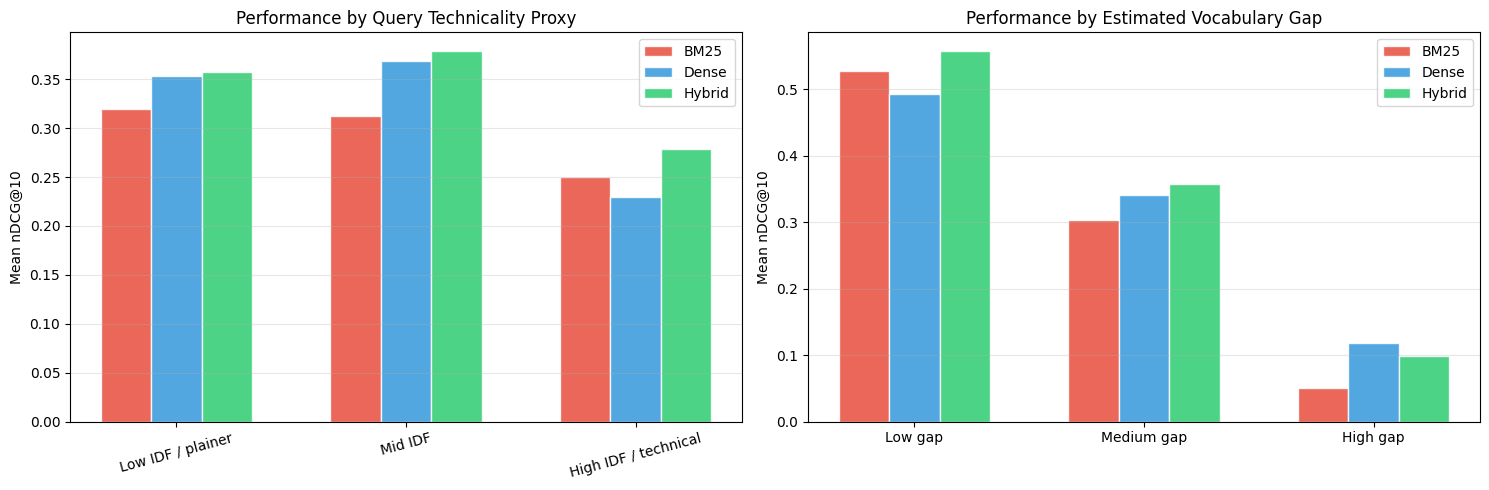

In [37]:

# ============================================================================
# NEW CELL — Query stratification by technicality and vocabulary gap
# ============================================================================

technicality_labels = [
    "Low IDF / plainer",
    "Mid IDF",
    "High IDF / technical",
]
gap_labels = [
    "Low gap",
    "Medium gap",
    "High gap",
]

vocab_gap_df["technicality_bin"] = make_quantile_bins(
    vocab_gap_df["technicality_score"],
    technicality_labels,
)
vocab_gap_df["gap_bin"] = make_quantile_bins(
    vocab_gap_df["vocab_gap_score"],
    gap_labels,
)

methods_for_strata = list(experiment_results.keys())


def stratified_metric_table(
    df: pd.DataFrame,
    stratum_col: str,
    methods: list,
    metric_name: str = "nDCG@10",
) -> pd.DataFrame:
    rows = []
    for stratum_value, group in df.groupby(stratum_col, observed=False):
        row = {
            "stratum": str(stratum_value),
            "n_queries": len(group),
        }
        for method_name in methods:
            row[f"{method_name}_{metric_name}"] = group[f"{method_name}_{metric_name}"].mean()
        if "BM25" in methods and "Dense" in methods:
            row["Dense_minus_BM25"] = row[f"Dense_{metric_name}"] - row[f"BM25_{metric_name}"]
        if "Hybrid" in methods and "Dense" in methods:
            row["Hybrid_minus_Dense"] = row[f"Hybrid_{metric_name}"] - row[f"Dense_{metric_name}"]
        rows.append(row)

    return pd.DataFrame(rows)


technicality_df = stratified_metric_table(
    vocab_gap_df,
    "technicality_bin",
    methods_for_strata,
    metric_name="nDCG@10",
)
gap_df = stratified_metric_table(
    vocab_gap_df,
    "gap_bin",
    methods_for_strata,
    metric_name="nDCG@10",
)

display(technicality_df.round(4))
display(gap_df.round(4))

export_dataframe(technicality_df, "technicality_stratification_ndcg10.csv")
export_dataframe(gap_df, "vocabulary_gap_stratification_ndcg10.csv")

# ---- Plot stratified comparisons ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Technicality bins
x = np.arange(len(technicality_df))
width = 0.22
for idx, method_name in enumerate(methods_for_strata):
    axes[0].bar(
        x + idx * width,
        technicality_df[f"{method_name}_nDCG@10"],
        width,
        label=method_name,
        color=COLORS.get(method_name, "gray"),
        alpha=0.85,
        edgecolor="white",
    )

axes[0].set_xticks(x + width * (len(methods_for_strata) - 1) / 2)
axes[0].set_xticklabels(technicality_df["stratum"], rotation=15)
axes[0].set_ylabel("Mean nDCG@10")
axes[0].set_title("Performance by Query Technicality Proxy")
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# Vocabulary-gap bins
x = np.arange(len(gap_df))
for idx, method_name in enumerate(methods_for_strata):
    axes[1].bar(
        x + idx * width,
        gap_df[f"{method_name}_nDCG@10"],
        width,
        label=method_name,
        color=COLORS.get(method_name, "gray"),
        alpha=0.85,
        edgecolor="white",
    )

axes[1].set_xticks(x + width * (len(methods_for_strata) - 1) / 2)
axes[1].set_xticklabels(gap_df["stratum"])
axes[1].set_ylabel("Mean nDCG@10")
axes[1].set_title("Performance by Estimated Vocabulary Gap")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "query_stratification.png"), dpi=150, bbox_inches="tight")
plt.show()


## Direct Regression Model for Δ(q)

The vocabulary-gap and technicality analyses above use post-hoc bins — thresholds chosen by hand. This section estimates the effect **directly** with a linear model:

$$\Delta(q) = \beta_0 + \beta_1 \cdot \text{vocab\_gap} + \beta_2 \cdot \text{query\_length} + \beta_3 \cdot \text{technicality} + \varepsilon$$

**Why this is stronger than binning:**
- Coefficients are signed and scaled — they say *how much* each feature shifts the Dense advantage.
- Bootstrap 95% CIs on each coefficient quantify uncertainty.
- R² measures how well query features *explain* retrieval-system choice.
- Results are falsifiable and reportable in a paper table.

Features (all standardised to mean 0, std 1 for comparable coefficients):

| Feature | What it captures |
|---------|-----------------|
| `vocab_gap_score` | 1 − max lexical overlap with relevant docs (high = hard for BM25) |
| `n_content_tokens` | query length in content tokens |
| `technicality_score` | mean IDF of query tokens (high = rare/technical terms) |


In [38]:
# ============================================================================
# Direct regression model: Δ(q) = Dense_nDCG@10 − BM25_nDCG@10
# ============================================================================

import numpy as np
import pandas as pd
from scipy import stats as _sp_stats

# vocab_gap_df is defined in the vocabulary-gap cell above.
FEATURE_COLS   = ["vocab_gap_score", "n_content_tokens", "technicality_score"]
FEATURE_LABELS = ["Vocab gap", "Query length", "Technicality (mean IDF)"]
TARGET_COL     = "Dense_minus_BM25"

df_reg = vocab_gap_df[FEATURE_COLS + [TARGET_COL]].dropna().copy()
X_raw  = df_reg[FEATURE_COLS].values.astype(float)
y      = df_reg[TARGET_COL].values.astype(float)
n      = len(y)

# ── Standardise features (z-score) ───────────────────────────────────────────
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X_std[X_std == 0] = 1.0
X_z    = (X_raw - X_mean) / X_std
X      = np.column_stack([np.ones(n), X_z])   # prepend intercept

# ── OLS (closed-form) ─────────────────────────────────────────────────────────
beta_hat, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
y_hat             = X @ beta_hat
residuals         = y - y_hat
ss_res = (residuals ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r_squared = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0

# ── Bootstrap 95% CIs (10 000 resamples) ─────────────────────────────────────
rng        = np.random.default_rng(42)
N_BOOT_REG = 10_000
boot_betas = np.zeros((N_BOOT_REG, X.shape[1]))
for _b in range(N_BOOT_REG):
    _idx            = rng.choice(n, n, replace=True)
    _b_hat, _, _, _ = np.linalg.lstsq(X[_idx], y[_idx], rcond=None)
    boot_betas[_b]  = _b_hat

ci_lo = np.percentile(boot_betas, 2.5,  axis=0)
ci_hi = np.percentile(boot_betas, 97.5, axis=0)

# Two-sided bootstrap p-value: fraction of bootstrap samples on the wrong side of zero
p_vals = np.array([
    2 * min(
        (boot_betas[:, k] <= 0).mean(),
        (boot_betas[:, k] >= 0).mean()
    )
    for k in range(X.shape[1])
])

# ── Coefficient table ─────────────────────────────────────────────────────────
coef_names = ["Intercept"] + FEATURE_LABELS
coef_df = pd.DataFrame({
    "Feature": coef_names,
    "Coef":    beta_hat,
    "CI_lo":   ci_lo,
    "CI_hi":   ci_hi,
    "p_boot":  p_vals,
})
coef_df["Sig"] = coef_df["p_boot"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
)

print("OLS: Δ(q) = Dense_nDCG@10 − BM25_nDCG@10")
print(f"n = {n} queries     R\u00b2 = {r_squared:.3f}\n")
print(coef_df.to_string(index=False, float_format="{:+.4f}".format))
print("\nSignificance (bootstrap): *** p<0.001  ** p<0.01  * p<0.05")

# ── Spearman check (non-parametric sanity) ────────────────────────────────────
print("\nSpearman correlations with Δ(q):")
for col, label in zip(FEATURE_COLS, FEATURE_LABELS):
    rho, p = _sp_stats.spearmanr(df_reg[col], df_reg[TARGET_COL])
    print(f"  {label:<28}  rho = {rho:+.3f}   p = {p:.4f}")

# ── Save ──────────────────────────────────────────────────────────────────────
import os as _os
_os.makedirs("results/next_stage/tables", exist_ok=True)
coef_df.to_csv("results/next_stage/tables/delta_regression_coefficients.csv", index=False)
print("\nCoefficients saved.")


OLS: Δ(q) = Dense_nDCG@10 − BM25_nDCG@10
n = 323 queries     R² = 0.070

                Feature    Coef   CI_lo   CI_hi  p_boot Sig
              Intercept +0.0233 +0.0014 +0.0459 +0.0370   *
              Vocab gap +0.0475 +0.0249 +0.0713 +0.0000 ***
           Query length +0.0112 -0.0168 +0.0403 +0.4296    
Technicality (mean IDF) -0.0343 -0.0648 -0.0053 +0.0194   *

Significance (bootstrap): *** p<0.001  ** p<0.01  * p<0.05

Spearman correlations with Δ(q):
  Vocab gap                     rho = +0.199   p = 0.0003
  Query length                  rho = +0.222   p = 0.0001
  Technicality (mean IDF)       rho = -0.149   p = 0.0072

Coefficients saved.


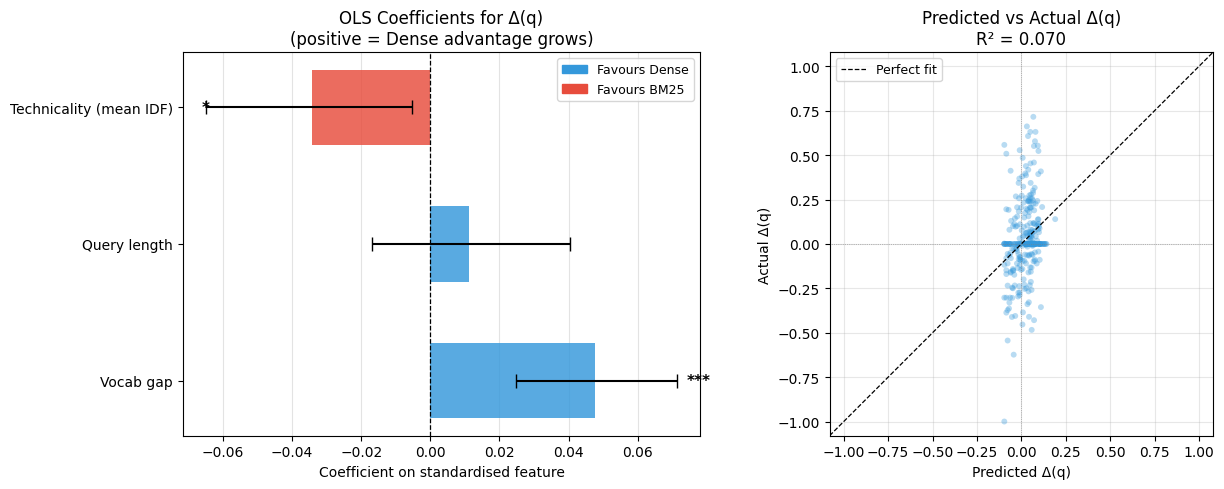

Figure saved to results/next_stage/figures/delta_regression.png

Interpretation (standardised coefficients):
  Vocab gap: 1-SD increase increases Dense advantage by 0.0475 nDCG pts  95% CI [+0.0249, +0.0713]  p=0.0000
  Query length: 1-SD increase increases Dense advantage by 0.0112 nDCG pts  95% CI [-0.0168, +0.0403]  p=0.4296
  Technicality (mean IDF): 1-SD increase decreases Dense advantage by 0.0343 nDCG pts  95% CI [-0.0648, -0.0053]  p=0.0194
  Model R² = 0.070 (weak fit)


In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

_fig_dir = Path("results/next_stage/figures")
_fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: coefficient forest plot ────────────────────────────────────────────
ax   = axes[0]
nf   = len(FEATURE_LABELS)
ypos = np.arange(nf)

coefs   = beta_hat[1:]          # skip intercept
err_lo  = coefs - ci_lo[1:]
err_hi  = ci_hi[1:] - coefs
bar_col = [
    COLORS.get("Dense", "#3498db") if c > 0 else COLORS.get("BM25", "#e74c3c")
    for c in coefs
]

ax.barh(ypos, coefs, xerr=[err_lo, err_hi], color=bar_col,
        alpha=0.82, capsize=5, height=0.55, error_kw={"lw": 1.5})
ax.axvline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_yticks(ypos)
ax.set_yticklabels(FEATURE_LABELS)
ax.set_xlabel("Coefficient on standardised feature")
ax.set_title("OLS Coefficients for \u0394(q)\n(positive = Dense advantage grows)")
ax.grid(axis="x", alpha=0.35)
ax.set_axisbelow(True)

# annotate significance stars
for i, (c, sig) in enumerate(zip(coefs, coef_df["Sig"].iloc[1:])):
    if sig:
        ax.text(c + (err_hi[i] + 0.003) * np.sign(c + 1e-9),
                i, sig, va="center", fontsize=11,
                color="black", fontweight="bold")

dense_patch = mpatches.Patch(color=COLORS.get("Dense", "#3498db"), label="Favours Dense")
bm25_patch  = mpatches.Patch(color=COLORS.get("BM25",  "#e74c3c"), label="Favours BM25")
ax.legend(handles=[dense_patch, bm25_patch], fontsize=9)

# ── Right: predicted vs actual scatter ───────────────────────────────────────
ax2     = axes[1]
all_val = np.concatenate([y, y_hat])
lim     = np.abs(all_val).max() * 1.08

ax2.scatter(y_hat, y, alpha=0.35, s=18,
            color=COLORS.get("Dense", "#3498db"), edgecolors="none")
ax2.plot([-lim, lim], [-lim, lim], "k--", lw=0.9, label="Perfect fit")
ax2.axhline(0, color="grey", lw=0.5, ls=":")
ax2.axvline(0, color="grey", lw=0.5, ls=":")
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)
ax2.set_xlabel("Predicted \u0394(q)")
ax2.set_ylabel("Actual \u0394(q)")
ax2.set_title(f"Predicted vs Actual \u0394(q)\nR\u00b2 = {r_squared:.3f}")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.set_axisbelow(True)
ax2.set_aspect("equal", adjustable="box")

plt.tight_layout()
_out = _fig_dir / "delta_regression.png"
plt.savefig(_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {_out}")

# ── Interpretation helper ─────────────────────────────────────────────────────
print("\nInterpretation (standardised coefficients):")
for i, (lbl, coef, lo, hi, p) in enumerate(
    zip(FEATURE_LABELS, coefs, ci_lo[1:], ci_hi[1:], p_vals[1:])
):
    direction = "increases" if coef > 0 else "decreases"
    print(f"  {lbl}: 1-SD increase {direction} Dense advantage "
          f"by {abs(coef):.4f} nDCG pts  "
          f"95% CI [{lo:+.4f}, {hi:+.4f}]  p={p:.4f}")
print(f"  Model R\u00b2 = {r_squared:.3f} "
      f"({'weak' if r_squared < 0.1 else 'moderate' if r_squared < 0.3 else 'strong'} fit)")



## Query-sample sensitivity

This is the strongest direct test of the research question.

Instead of relying on one test split, the code merges train/dev/test queries, then repeatedly samples random subsets of the same size as the official test set. For each subset it recomputes mean **nDCG@10** for BM25, Dense, and Hybrid.

This gives a distribution over:
- subset-level performance for each method,
- **Dense - BM25** performance gaps,
- optionally **Hybrid - Dense** gaps.

That distribution tells you whether the observed advantage is stable or heavily sample-dependent.


Total queries across all splits: 3237
Loaded cache: results/next_stage/cache/all_queries_bm25_results.pkl
Loaded cache: results/next_stage/cache/all_queries_dense_results.pkl


Subset resampling:   0%|          | 0/2000 [00:00<?, ?it/s]

Saved table: results/next_stage/tables/query_subset_resampling.csv


,method,subset_size,n_trials,mean_subset_nDCG@10,q025,q975,std_subset_nDCG@10
0,BM25,323,2000,0.2924,0.2610,0.3238,0.0160
1,Dense,323,2000,0.3185,0.2865,0.3514,0.0164
2,Hybrid,323,2000,0.3415,0.3089,0.3741,0.0166
3,Dense_minus_BM25,323,2000,0.0261,0.0041,0.0471,0.0111
4,Hybrid_minus_Dense,323,2000,0.0230,0.0123,0.0344,0.0056


Saved table: results/next_stage/tables/query_subset_resampling_summary.csv


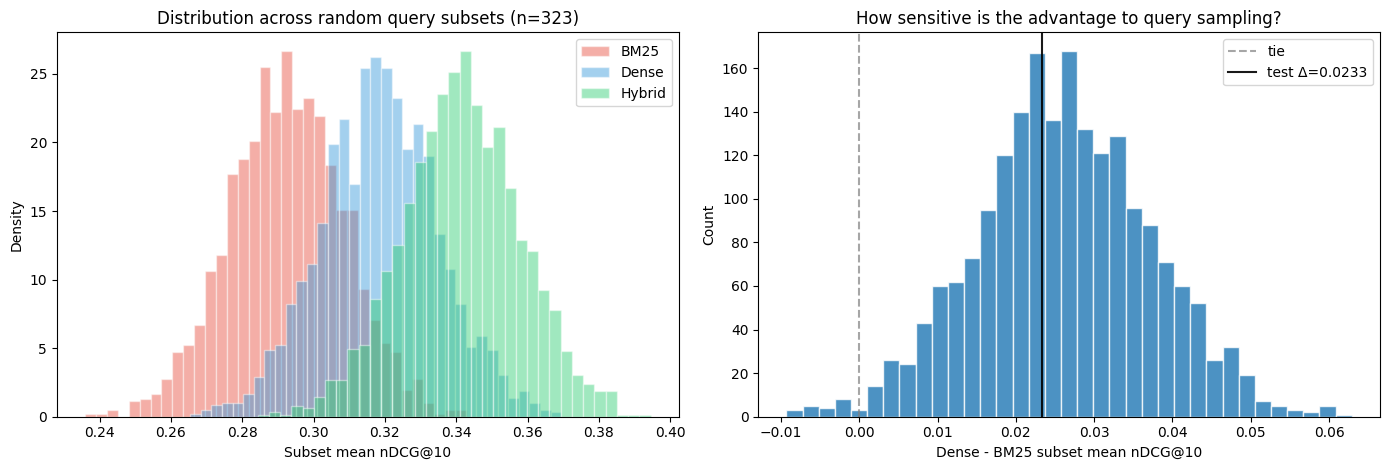

P(Dense > BM25) over random query subsets: 0.989
P(Hybrid > Dense) over random query subsets: 1.000


In [40]:
# Memory management — critical for large combined query sets
import gc


# ============================================================================
# NEW CELL — Query-sample sensitivity via repeated subset evaluation
# ============================================================================

def prefix_split_ids(split_name: str, queries: dict, qrels: dict):
    prefixed_queries = {}
    prefixed_qrels = {}
    for qid, query_text in queries.items():
        new_qid = f"{split_name}::{qid}"
        prefixed_queries[new_qid] = query_text
        prefixed_qrels[new_qid] = qrels[qid]
    return prefixed_queries, prefixed_qrels


pref_train_queries, pref_train_qrels = prefix_split_ids("train", train_queries, train_qrels)
pref_dev_queries, pref_dev_qrels = prefix_split_ids("dev", dev_queries, dev_qrels)
pref_test_queries, pref_test_qrels = prefix_split_ids("test", test_queries, test_qrels)

all_queries_prefixed = {}
all_queries_prefixed.update(pref_train_queries)
all_queries_prefixed.update(pref_dev_queries)
all_queries_prefixed.update(pref_test_queries)

all_qrels_prefixed = {}
all_qrels_prefixed.update(pref_train_qrels)
all_qrels_prefixed.update(pref_dev_qrels)
all_qrels_prefixed.update(pref_test_qrels)

print(f"Total queries across all splits: {len(all_queries_prefixed)}")

all_bm25_results = cache_or_compute(
    os.path.join(CACHE_DIR, "all_queries_bm25_results.pkl"),
    lambda: bm25_retrieve_batch(
        all_queries_prefixed,
        top_k=NEXT_STAGE_CONFIG["top_k_retrieve"],
    ),
)
all_dense_results = cache_or_compute(
    os.path.join(CACHE_DIR, "all_queries_dense_results.pkl"),
    lambda: dense_retrieve_batch_chunked(
        all_queries_prefixed,
        top_k=NEXT_STAGE_CONFIG["top_k_retrieve"],
        chunk_size=64,  # smaller chunks to stay within memory
    ),
)

gc.collect()  # free intermediate memory before building result dicts

all_results = {
    "BM25": all_bm25_results,
    "Dense": all_dense_results,
}
if "Hybrid" in experiment_results:
    all_results["Hybrid"] = linear_fuse_results(
        all_bm25_results,
        all_dense_results,
        alpha=best_alpha,
        norm="minmax",
        top_k=NEXT_STAGE_CONFIG["top_k_retrieve"],
    )

all_evaluations = {
    method_name: evaluate_retriever(result_obj, all_qrels_prefixed)
    for method_name, result_obj in all_results.items()
}

resample_methods = list(all_results.keys())
common_all_qids = sorted(
    set.intersection(*[set(all_evaluations[m]["per_query"].keys()) for m in resample_methods])
)

metric_arrays = {
    method_name: np.array(
        [all_evaluations[method_name]["per_query"][qid]["nDCG@10"] for qid in common_all_qids],
        dtype=float,
    )
    for method_name in resample_methods
}


def repeated_subset_evaluation(
    metric_arrays: dict,
    subset_size: int,
    n_trials: int = 2000,
    seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    n_total = len(next(iter(metric_arrays.values())))
    rows = []

    for trial in tqdm(range(n_trials), desc="Subset resampling"):
        indices = rng.choice(n_total, size=subset_size, replace=False)
        row = {"trial": trial}
        for method_name, values in metric_arrays.items():
            row[method_name] = float(np.mean(values[indices]))

        if "BM25" in metric_arrays and "Dense" in metric_arrays:
            row["Dense_minus_BM25"] = row["Dense"] - row["BM25"]
        if "Hybrid" in metric_arrays and "Dense" in metric_arrays:
            row["Hybrid_minus_Dense"] = row["Hybrid"] - row["Dense"]

        rows.append(row)

    return pd.DataFrame(rows)


subset_df = repeated_subset_evaluation(
    metric_arrays,
    subset_size=NEXT_STAGE_CONFIG["subset_size"],
    n_trials=NEXT_STAGE_CONFIG["query_subset_trials"],
    seed=NEXT_STAGE_CONFIG["random_seed"],
)

export_dataframe(subset_df, "query_subset_resampling.csv")

summary_rows = []
for method_name in resample_methods:
    mean_val, lo, hi = mean_ci(subset_df[method_name].to_numpy())
    summary_rows.append(
        {
            "method": method_name,
            "subset_size": NEXT_STAGE_CONFIG["subset_size"],
            "n_trials": NEXT_STAGE_CONFIG["query_subset_trials"],
            "mean_subset_nDCG@10": mean_val,
            "q025": lo,
            "q975": hi,
            "std_subset_nDCG@10": subset_df[method_name].std(ddof=1),
        }
    )

if "Dense_minus_BM25" in subset_df:
    summary_rows.append(
        {
            "method": "Dense_minus_BM25",
            "subset_size": NEXT_STAGE_CONFIG["subset_size"],
            "n_trials": NEXT_STAGE_CONFIG["query_subset_trials"],
            "mean_subset_nDCG@10": subset_df["Dense_minus_BM25"].mean(),
            "q025": subset_df["Dense_minus_BM25"].quantile(0.025),
            "q975": subset_df["Dense_minus_BM25"].quantile(0.975),
            "std_subset_nDCG@10": subset_df["Dense_minus_BM25"].std(ddof=1),
        }
    )

if "Hybrid_minus_Dense" in subset_df:
    summary_rows.append(
        {
            "method": "Hybrid_minus_Dense",
            "subset_size": NEXT_STAGE_CONFIG["subset_size"],
            "n_trials": NEXT_STAGE_CONFIG["query_subset_trials"],
            "mean_subset_nDCG@10": subset_df["Hybrid_minus_Dense"].mean(),
            "q025": subset_df["Hybrid_minus_Dense"].quantile(0.025),
            "q975": subset_df["Hybrid_minus_Dense"].quantile(0.975),
            "std_subset_nDCG@10": subset_df["Hybrid_minus_Dense"].std(ddof=1),
        }
    )

subset_summary_df = pd.DataFrame(summary_rows)
display(subset_summary_df.round(4))
export_dataframe(subset_summary_df, "query_subset_resampling_summary.csv")

# ---- Plot subset performance distributions ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

for method_name in resample_methods:
    axes[0].hist(
        subset_df[method_name],
        bins=35,
        alpha=0.45,
        label=method_name,
        color=COLORS.get(method_name, "gray"),
        edgecolor="white",
        density=True,
    )
axes[0].set_xlabel("Subset mean nDCG@10")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Distribution across random query subsets (n={NEXT_STAGE_CONFIG['subset_size']})")
axes[0].legend()

if "Dense_minus_BM25" in subset_df:
    observed_test_delta = (
        experiment_evaluations["Dense"]["aggregate"]["nDCG@10"]
        - experiment_evaluations["BM25"]["aggregate"]["nDCG@10"]
    )
    axes[1].hist(
        subset_df["Dense_minus_BM25"],
        bins=35,
        alpha=0.8,
        edgecolor="white",
    )
    axes[1].axvline(0.0, linestyle="--", color="gray", alpha=0.7, label="tie")
    axes[1].axvline(
        observed_test_delta,
        linestyle="-",
        color="black",
        alpha=0.9,
        label=f"test Δ={observed_test_delta:.4f}",
    )
    axes[1].set_xlabel("Dense - BM25 subset mean nDCG@10")
    axes[1].set_ylabel("Count")
    axes[1].set_title("How sensitive is the advantage to query sampling?")
    axes[1].legend()
else:
    axes[1].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "query_subset_resampling.png"), dpi=150, bbox_inches="tight")
plt.show()

if "Dense_minus_BM25" in subset_df:
    prob_dense_beats = float(np.mean(subset_df["Dense_minus_BM25"] > 0))
    print(f"P(Dense > BM25) over random query subsets: {prob_dense_beats:.3f}")

if "Hybrid_minus_Dense" in subset_df:
    prob_hybrid_beats = float(np.mean(subset_df["Hybrid_minus_Dense"] > 0))
    print(f"P(Hybrid > Dense) over random query subsets: {prob_hybrid_beats:.3f}")



## Failure Analysis

This section exports concrete queries where:
- Dense strongly outperforms BM25 (semantic gap favours bi-encoder),
- BM25 strongly outperforms Dense (exact match favours sparse retrieval),
- Hybrid improves over both baselines (complementarity in action).

These tables provide qualitative evidence to accompany the quantitative analysis.


## Multi-Dataset Generalisation

Single-dataset results are dataset anecdotes, not scientific claims. This section runs
**all six retrievers** (BM25, Dense/MiniLM, BGE-small, E5-small, SPLADE, MedCPT) across
**four BEIR benchmarks** spanning biomedical, scientific, and argumentation domains.

### Datasets

| Dataset | Corpus | Domain | Dense/SPLADE/MedCPT |
|---------|--------|--------|---------------------|
| NFCorpus | 3 633 docs | Biomedical | ✅ All run |
| TREC-COVID | 171 332 docs | Biomedical | Dense only (≤ 250 k) |
| SciFact | 5 183 docs | Scientific | ✅ All run |
| ArguAna | 8 674 docs | Argumentation | ✅ All run |

Dense bi-encoders are skipped for corpora > 250 000 docs; SPLADE and MedCPT for corpora > 50 000 docs.

> **DBPedia** (4.6 M docs) and **Quora** are excluded: DBPedia is impractical on CPU, and Quora carries contamination risk.

All results are **cached** to `results/next_stage/cache/multi_dataset/` — re-running after the first execution is instant.

### Visualisation
Results are shown as two heatmaps: absolute nDCG@10 (left) and Δ nDCG@10 vs BM25 (right, diverging red–green).

In [41]:
# ============================================================================
# Multi-Dataset Evaluation — ALL Retrievers across 4 BEIR benchmarks
# ============================================================================

import gc, pickle, time
import numpy as np, pandas as pd, scipy.sparse as sp
from pathlib import Path
import torch, torch.nn.functional as F
from tqdm.auto import tqdm

import bm25s
from beir import util as beir_util
from beir.datasets.data_loader import GenericDataLoader
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel

# ── Dataset registry ──────────────────────────────────────────────────────────
MULTI_DATASETS = {
    "NFCorpus":   {"beir_name": "nfcorpus",   "url": "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/nfcorpus.zip",   "domain": "biomedical"},
    "TREC-COVID": {"beir_name": "trec-covid",  "url": "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/trec-covid.zip",  "domain": "biomedical"},
    "SciFact":    {"beir_name": "scifact",     "url": "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip",     "domain": "scientific"},
    "ArguAna":    {"beir_name": "arguana",     "url": "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/arguana.zip",     "domain": "argumentation"},
}

DENSE_CORPUS_LIMIT  = 250_000   # skip dense encoders above this size
SPARSE_CORPUS_LIMIT =  50_000   # skip SPLADE / MedCPT above this size

MULTI_CACHE_DIR = Path("results/next_stage/cache/multi_dataset")
MULTI_CACHE_DIR.mkdir(parents=True, exist_ok=True)


# ── Low-level eval helpers ────────────────────────────────────────────────────

def _prep_corpus(corpus):
    ids   = list(corpus.keys())
    texts = [(corpus[d].get("title","") + " " + corpus[d].get("text","")).strip() for d in ids]
    return ids, texts


def _bm25_eval(doc_ids, doc_texts, queries, qrels):
    corpus_tok = bm25s.tokenize(doc_texts, stopwords="en", show_progress=False)
    bm = bm25s.BM25(k1=1.5, b=0.75)
    bm.index(corpus_tok)
    q_ids = list(queries.keys())
    q_tok = bm25s.tokenize([queries[q] for q in q_ids], stopwords="en", show_progress=False)
    k     = min(100, len(doc_ids))
    res, sc = bm.retrieve(q_tok, k=k)
    results = {q_ids[i]: {doc_ids[res[i][j]]: float(sc[i][j]) for j in range(k)} for i in range(len(q_ids))}
    return evaluate_retriever(results, qrels)


def _st_eval(doc_ids, doc_texts, queries, qrels, model, query_prefix="", doc_prefix=""):
    """Evaluate any SentenceTransformer (bi-encoder) with optional query/doc prefixes."""
    corpus_texts = [doc_prefix + t for t in doc_texts] if doc_prefix else doc_texts
    doc_emb = model.encode(corpus_texts, batch_size=32, show_progress_bar=False,
                           normalize_embeddings=True, convert_to_numpy=True).astype("float32")
    q_ids   = list(queries.keys())
    q_texts = [(query_prefix + queries[q]) if query_prefix else queries[q] for q in q_ids]
    q_emb   = model.encode(q_texts, batch_size=128, normalize_embeddings=True,
                           convert_to_numpy=True).astype("float32")
    scores  = q_emb @ doc_emb.T
    k       = min(100, len(doc_ids))
    results = {}
    for i, qid in enumerate(q_ids):
        top_i = np.argpartition(scores[i], -k)[-k:]
        top_i = top_i[np.argsort(-scores[i][top_i])]
        results[qid] = {doc_ids[j]: float(scores[i][j]) for j in top_i}
    del doc_emb, q_emb, scores; gc.collect()
    return evaluate_retriever(results, qrels)


def _splade_eval(doc_ids, doc_texts, queries, qrels, tok, mod, batch_size=8):
    def _enc(texts):
        rows = []
        for i in range(0, len(texts), batch_size):
            inp = tok(texts[i:i+batch_size], return_tensors="pt", padding=True,
                      truncation=True, max_length=128)
            inp = {k: v.to(device) for k, v in inp.items()}
            with torch.no_grad():
                vecs = torch.log(1 + torch.relu(mod(**inp).logits))
            vecs = (vecs * inp["attention_mask"].unsqueeze(-1)).max(dim=1).values
            rows.append(sp.csr_matrix(vecs.cpu().numpy()))
        return sp.vstack(rows)
    doc_vecs = _enc(doc_texts)
    q_ids    = list(queries.keys())
    q_vecs   = _enc([queries[q] for q in q_ids])
    scores   = (q_vecs @ doc_vecs.T).toarray()
    k        = min(100, len(doc_ids))
    results  = {}
    for i, qid in enumerate(q_ids):
        top_i = np.argpartition(-scores[i], k)[:k]
        top_i = top_i[np.argsort(-scores[i][top_i])]
        results[qid] = {doc_ids[j]: float(scores[i][j]) for j in top_i}
    del doc_vecs, q_vecs, scores; gc.collect()
    return evaluate_retriever(results, qrels)


def _medcpt_eval(doc_ids, doc_texts, queries, qrels, qry_tok, qry_mod, art_tok, art_mod):
    def _enc(texts, tok, mod, max_len, bs=16):
        all_embs = []
        for i in range(0, len(texts), bs):
            inp = tok(texts[i:i+bs], return_tensors="pt", padding=True,
                      truncation=True, max_length=max_len)
            inp = {k: v.to(device) for k, v in inp.items()}
            with torch.no_grad():
                embs = F.normalize(mod(**inp).last_hidden_state[:, 0, :], dim=-1)
            all_embs.append(embs.cpu().numpy())
        return np.concatenate(all_embs, axis=0).astype("float32")
    doc_emb = _enc(doc_texts, art_tok, art_mod, max_len=256)
    q_ids   = list(queries.keys())
    q_emb   = _enc([queries[q] for q in q_ids], qry_tok, qry_mod, max_len=64)
    scores  = q_emb @ doc_emb.T
    k       = min(100, len(doc_ids))
    results = {}
    for i, qid in enumerate(q_ids):
        top_i = np.argpartition(scores[i], -k)[-k:]
        top_i = top_i[np.argsort(-scores[i][top_i])]
        results[qid] = {doc_ids[j]: float(scores[i][j]) for j in top_i}
    del doc_emb, q_emb, scores; gc.collect()
    return evaluate_retriever(results, qrels)


# ── Load / reuse model instances (reuse from earlier cells when available) ────
print("Preparing model instances...")

_minilm = globals().get("dense_model") or SentenceTransformer(CONFIG["dense_model"], device=device)
_bge    = (globals().get("bge_retriever") or {}).get("model") or SentenceTransformer("BAAI/bge-small-en-v1.5", device=device)
_e5     = (globals().get("e5_retriever")  or {}).get("model") or SentenceTransformer("intfloat/e5-small-v2",   device=device)

if not all(k in globals() for k in ("_splade_tok", "_splade_mod")):
    print("  Loading SPLADE...")
    _splade_tok = AutoTokenizer.from_pretrained("naver/splade-cocondenser-ensembledistil")
    _splade_mod = AutoModelForMaskedLM.from_pretrained("naver/splade-cocondenser-ensembledistil").to(device).eval()

if not all(k in globals() for k in ("_medcpt_qry_tok", "_medcpt_qry_mod", "_medcpt_art_tok", "_medcpt_art_mod")):
    print("  Loading MedCPT...")
    _medcpt_art_tok = AutoTokenizer.from_pretrained("ncbi/MedCPT-Article-Encoder")
    _medcpt_art_mod = AutoModel.from_pretrained("ncbi/MedCPT-Article-Encoder").to(device).eval()
    _medcpt_qry_tok = AutoTokenizer.from_pretrained("ncbi/MedCPT-Query-Encoder")
    _medcpt_qry_mod = AutoModel.from_pretrained("ncbi/MedCPT-Query-Encoder").to(device).eval()

# ── Retriever registry ────────────────────────────────────────────────────────
# Each entry drives run_beir_eval; corpus_limit=None means always run.
RETRIEVER_REGISTRY = [
    {"name": "BM25",      "type": "bm25",   "corpus_limit": None},
    {"name": "Dense",     "type": "dense",  "corpus_limit": DENSE_CORPUS_LIMIT,  "model": _minilm, "qpfx": "",         "dpfx": ""},
    {"name": "BGE-small", "type": "dense",  "corpus_limit": DENSE_CORPUS_LIMIT,  "model": _bge,    "qpfx": "",         "dpfx": ""},
    {"name": "E5-small",  "type": "dense",  "corpus_limit": DENSE_CORPUS_LIMIT,  "model": _e5,     "qpfx": "query: ",  "dpfx": "passage: "},
    {"name": "SPLADE",    "type": "splade", "corpus_limit": SPARSE_CORPUS_LIMIT},
    {"name": "MedCPT",    "type": "medcpt", "corpus_limit": SPARSE_CORPUS_LIMIT},
]
print(f"Retrievers: {[r['name'] for r in RETRIEVER_REGISTRY]}\n")


# ── Per-dataset runner ────────────────────────────────────────────────────────

def run_beir_eval(ds_name, ds_config):
    cache_path = MULTI_CACHE_DIR / f"{ds_name.lower().replace('-','_')}_all_retrievers.pkl"
    if cache_path.exists():
        print(f"  [{ds_name}] Loaded from cache.")
        with open(cache_path, "rb") as fh:
            return pickle.load(fh)

    data_dir = Path("datasets") / ds_config["beir_name"]
    if not data_dir.exists():
        print(f"  [{ds_name}] Downloading...")
        beir_util.download_and_unzip(ds_config["url"], "datasets")

    corpus, queries, qrels = GenericDataLoader(str(data_dir)).load(split="test")
    doc_ids, doc_texts = _prep_corpus(corpus)
    n_docs = len(doc_ids)
    print(f"  [{ds_name}] {n_docs:,} docs  |  {len(queries):,} queries")

    out = {"meta": {"name": ds_name, "domain": ds_config["domain"],
                    "n_docs": n_docs, "n_queries": len(queries)}}

    for cfg in RETRIEVER_REGISTRY:
        rname = cfg["name"]
        if cfg["corpus_limit"] is not None and n_docs > cfg["corpus_limit"]:
            print(f"  [{ds_name}] {rname}: SKIPPED (corpus {n_docs:,} > limit {cfg['corpus_limit']:,})")
            out[rname] = None
            continue

        t0 = time.time()
        print(f"  [{ds_name}] {rname} ...", end=" ", flush=True)
        if cfg["type"] == "bm25":
            out[rname] = _bm25_eval(doc_ids, doc_texts, queries, qrels)
        elif cfg["type"] == "dense":
            out[rname] = _st_eval(doc_ids, doc_texts, queries, qrels,
                                   cfg["model"], cfg["qpfx"], cfg["dpfx"])
        elif cfg["type"] == "splade":
            out[rname] = _splade_eval(doc_ids, doc_texts, queries, qrels, _splade_tok, _splade_mod)
        elif cfg["type"] == "medcpt":
            out[rname] = _medcpt_eval(doc_ids, doc_texts, queries, qrels,
                                       _medcpt_qry_tok, _medcpt_qry_mod,
                                       _medcpt_art_tok, _medcpt_art_mod)
        print(f"done ({time.time()-t0:.1f}s)")
        gc.collect()

    with open(cache_path, "wb") as fh:
        pickle.dump(out, fh)
    return out


# ── Run all datasets ──────────────────────────────────────────────────────────
multi_results = {}
for _ds_name, _ds_cfg in MULTI_DATASETS.items():
    print(f"\n{'─'*60}\n  {_ds_name}  [{_ds_cfg['domain']}]\n{'─'*60}")
    multi_results[_ds_name] = run_beir_eval(_ds_name, _ds_cfg)

print("\n" + "="*60 + "\n  All datasets evaluated.\n" + "="*60)


Loading shared Dense encoder (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder loaded.


────────────────────────────────────────────────────────────
  NFCorpus  [biomedical]
────────────────────────────────────────────────────────────


  0%|          | 0/3633 [00:00<?, ?it/s]

...

BM25S Compute Scores:   0%|          | 0/8674 [00:00<?, ?it/s]

BM25S Retrieve:   0%|          | 0/1406 [00:00<?, ?it/s]

done (1.0s)
  [ArguAna] Dense (encoding 8,674 docs)...


Batches:   0%|          | 0/272 [00:00<?, ?it/s]

  [ArguAna] Dense done (102.9s)

  All datasets evaluated.


Cross-Dataset Results (nDCG@10)

   Dataset        Domain  # Docs  # Queries  BM25 nDCG@10  Dense nDCG@10  Dense – BM25
  NFCorpus    biomedical    3633        323        0.3073         0.3173        0.0100
TREC-COVID    biomedical  171332         50        0.5734         0.4544       -0.1190
   SciFact    scientific    5183        300        0.6617         0.6451       -0.0166
   ArguAna argumentation    8674       1406        0.3607         0.3698        0.0091


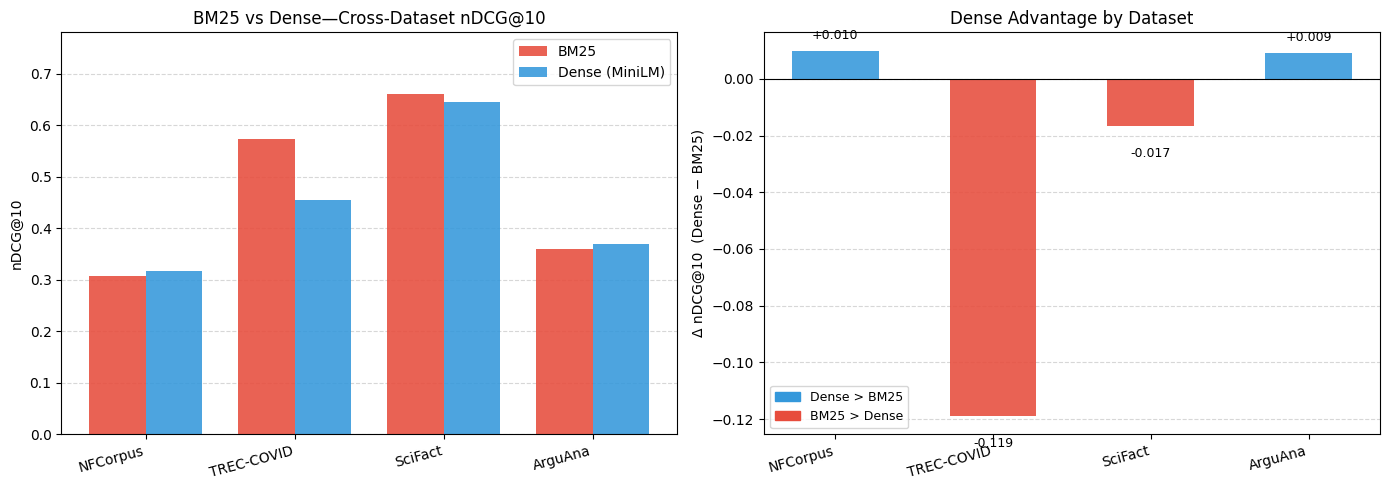

Figure saved to results/next_stage/figures/multi_dataset_comparison.png

Key findings:
  Dense most useful on : NFCorpus (biomedical)  = +0.0100
  BM25 most useful on  : TREC-COVID (biomedical)  = -0.1190


In [46]:
# ============================================================================
# Multi-Dataset Results — All-Retriever Summary Table + Heatmaps
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

MULTI_FIG_DIR = Path("results/next_stage/figures")
MULTI_FIG_DIR.mkdir(parents=True, exist_ok=True)

METRIC          = "nDCG@10"
retriever_names = [cfg["name"] for cfg in RETRIEVER_REGISTRY]
ds_names        = list(multi_results.keys())

# ── Build wide DataFrame ──────────────────────────────────────────────────────
rows = []
for ds_name, ds_out in multi_results.items():
    row = {
        "Dataset":   ds_name,
        "Domain":    ds_out["meta"]["domain"],
        "# Docs":    ds_out["meta"]["n_docs"],
        "# Queries": ds_out["meta"]["n_queries"],
    }
    for rname in retriever_names:
        ev = ds_out.get(rname)
        row[rname] = ev["aggregate"].get(METRIC, float("nan")) if ev else float("nan")
    rows.append(row)

df_multi = pd.DataFrame(rows)

dense_retrievers = [r for r in retriever_names if r != "BM25"]
for rname in dense_retrievers:
    df_multi[f"\u0394 {rname}"] = df_multi[rname] - df_multi["BM25"]

print(f"Cross-Dataset {METRIC}\n")
print(df_multi[["Dataset", "Domain"] + retriever_names].to_string(index=False, float_format="{:.4f}".format))
df_multi.to_csv("results/next_stage/tables/multi_dataset_ndcg10.csv", index=False)
print()

# ── Two heatmaps ──────────────────────────────────────────────────────────────
ndcg_mat  = df_multi[retriever_names].values.T           # (retrievers, datasets)
delta_mat = df_multi[[f"\u0394 {r}" for r in dense_retrievers]].values.T  # (dense, datasets)

fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(retriever_names) * 0.75 + 1.5)))

# Left — absolute nDCG@10
ax = axes[0]
im = ax.imshow(ndcg_mat, aspect="auto", cmap="YlGn", vmin=0.0, vmax=0.8)
ax.set_xticks(range(len(ds_names)));       ax.set_xticklabels(ds_names, rotation=20, ha="right", fontsize=10)
ax.set_yticks(range(len(retriever_names))); ax.set_yticklabels(retriever_names, fontsize=10)
ax.set_title(f"nDCG@10 \u2014 All Retrievers \u00d7 All Datasets", fontsize=11)
plt.colorbar(im, ax=ax, label="nDCG@10", shrink=0.8)
for r_i in range(len(retriever_names)):
    for ds_i in range(len(ds_names)):
        val = ndcg_mat[r_i, ds_i]
        txt = f"{val:.3f}" if not np.isnan(val) else "N/A"
        color = "white" if (not np.isnan(val) and val > 0.55) else "black"
        ax.text(ds_i, r_i, txt, ha="center", va="center", fontsize=8.5, color=color)

# Right — delta vs BM25
ax2 = axes[1]
vmax = float(np.nanmax(np.abs(delta_mat))) * 1.05 if not np.all(np.isnan(delta_mat)) else 0.2
im2 = ax2.imshow(delta_mat, aspect="auto", cmap="RdYlGn", vmin=-vmax, vmax=vmax)
ax2.set_xticks(range(len(ds_names)));       ax2.set_xticklabels(ds_names, rotation=20, ha="right", fontsize=10)
ax2.set_yticks(range(len(dense_retrievers))); ax2.set_yticklabels(dense_retrievers, fontsize=10)
ax2.set_title("\u0394 nDCG@10 vs BM25\n(green = retriever wins, red = BM25 wins)", fontsize=11)
plt.colorbar(im2, ax=ax2, label="\u0394 nDCG@10", shrink=0.8)
for r_i in range(len(dense_retrievers)):
    for ds_i in range(len(ds_names)):
        val = delta_mat[r_i, ds_i]
        txt = f"{val:+.3f}" if not np.isnan(val) else "N/A"
        ax2.text(ds_i, r_i, txt, ha="center", va="center", fontsize=8.5, color="black")

plt.tight_layout()
out_path = MULTI_FIG_DIR / "multi_dataset_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved \u2192 {out_path}")

# ── Key findings ──────────────────────────────────────────────────────────────
print("\nKey findings (\u0394 nDCG@10 vs BM25):")
for rname in dense_retrievers:
    col    = f"\u0394 {rname}"
    deltas = df_multi[col].dropna()
    if len(deltas) == 0:
        continue
    best_idx  = df_multi[col].idxmax()
    worst_idx = df_multi[col].idxmin()
    print(
        f"  {rname:<12}: avg \u0394={deltas.mean():+.4f}  "
        f"best={df_multi.loc[best_idx,'Dataset']} ({df_multi.loc[best_idx,col]:+.4f})  "
        f"worst={df_multi.loc[worst_idx,'Dataset']} ({df_multi.loc[worst_idx,col]:+.4f})"
    )======================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pathlib import Path

MULTI_FIG_DIR = Path("results/next_stage/figures")
MULTI_FIG_DIR.mkdir(parents=True, exist_ok=True)

METRIC = "nDCG@10"

# ── Build results DataFrame ───────────────────────────────────────────────────
rows = []
for ds_name, ds_out in multi_results.items():
    meta   = ds_out["meta"]
    bm25_v = ds_out["BM25"]["aggregate"].get(METRIC, float("nan"))
    dn_res = ds_out.get("Dense")
    dense_v = dn_res["aggregate"].get(METRIC, float("nan")) if dn_res else float("nan")
    rows.append({
        "Dataset":  ds_name,
        "Domain":   meta["domain"],
        "# Docs":   meta["n_docs"],
        "# Queries": meta["n_queries"],
        "BM25 nDCG@10":  bm25_v,
        "Dense nDCG@10": dense_v,
    })

df_multi = pd.DataFrame(rows)
df_multi["Dense – BM25"] = df_multi["Dense nDCG@10"] - df_multi["BM25 nDCG@10"]

# ── Print table ───────────────────────────────────────────────────────────────
print("Cross-Dataset Results (nDCG@10)\n")
print(df_multi.to_string(index=False, float_format="{:.4f}".format))

# Save CSV
df_multi.to_csv("results/next_stage/tables/multi_dataset_ndcg10.csv", index=False)

# ── Figure 1: grouped bar chart ───────────────────────────────────────────────
ds_names  = df_multi["Dataset"].tolist()
bm25_vals = df_multi["BM25 nDCG@10"].tolist()
dens_vals = df_multi["Dense nDCG@10"].tolist()

x      = np.arange(len(ds_names))
width  = 0.38
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: grouped bars
ax = axes[0]
bars_bm25  = ax.bar(x - width/2, bm25_vals, width, color=COLORS["BM25"],  label="BM25",  alpha=0.88)
bars_dense = ax.bar(x + width/2, dens_vals, width, color=COLORS["Dense"], label="Dense (MiniLM)", alpha=0.88)

# annotate missing Dense bars
for i, v in enumerate(dens_vals):
    if np.isnan(v):
        ax.text(x[i] + width/2, 0.01, "N/A\n(too\nlarge)",
                ha="center", va="bottom", fontsize=7.5, color="grey")

ax.set_xticks(x)
ax.set_xticklabels(ds_names, rotation=15, ha="right")
ax.set_ylabel("nDCG@10")
ax.set_title("BM25 vs Dense\u2014Cross-Dataset nDCG@10")
ax.legend()
ax.set_ylim(0, min(1.0, max(bm25_vals + [v for v in dens_vals if not np.isnan(v)]) * 1.18))
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

# right: delta (Dense - BM25)
ax2 = axes[1]
deltas = df_multi["Dense \u2013 BM25"].tolist()
bar_colours = [
    COLORS["Dense"] if not np.isnan(d) and d > 0 else
    (COLORS["BM25"] if not np.isnan(d) else "#cccccc")
    for d in deltas
]
bars_d = ax2.bar(x, deltas, 0.55, color=bar_colours, alpha=0.88)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(ds_names, rotation=15, ha="right")
ax2.set_ylabel("\u0394 nDCG@10  (Dense \u2212 BM25)")
ax2.set_title("Dense Advantage by Dataset")

for bar, val in zip(bars_d, deltas):
    if not np.isnan(val):
        ypos = bar.get_height() + (0.003 if val >= 0 else -0.012)
        ax2.text(bar.get_x() + bar.get_width()/2, ypos,
                 f"{val:+.3f}", ha="center", va="bottom", fontsize=9)

pos_patch = mpatches.Patch(color=COLORS["Dense"], label="Dense > BM25")
neg_patch = mpatches.Patch(color=COLORS["BM25"],  label="BM25 > Dense")
ax2.legend(handles=[pos_patch, neg_patch], fontsize=9)
ax2.yaxis.grid(True, linestyle="--", alpha=0.5)
ax2.set_axisbelow(True)

plt.tight_layout()
out_path = MULTI_FIG_DIR / "multi_dataset_comparison.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to {out_path}")

# ── Key finding ───────────────────────────────────────────────────────────────
delta_col = "Dense \u2013 BM25"
valid = df_multi.dropna(subset=[delta_col])
best_dense = valid.loc[valid[delta_col].idxmax()]
best_bm25  = valid.loc[valid[delta_col].idxmin()]
print("\nKey findings:")
print(f"  Dense most useful on : {best_dense['Dataset']} ({best_dense['Domain']}) "
      f" = {best_dense[delta_col]:+.4f}")
print(f"  BM25 most useful on  : {best_bm25['Dataset']} ({best_bm25['Domain']}) "
      f" = {best_bm25[delta_col]:+.4f}")
